## Week 3: Shallow Neural Networks - Jupyter Notebook

_Neural Networks and Deep Learning - Course 1_


### Setup and Imports

In [4]:

%pip install scikit-learn

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Week 3: Shallow Neural Networks")
print("Environment setup complete!")


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Week 3: Shallow Neural Networks
Environment setup complete!


## 1.Neural Network Representation

### Understanding the 2-Layer Network Structure

```mermaid
graph LR
    X[X<br/>3×1] --> H[Hidden<br/>4 units] --> Y[ŷ<br/>1×1]

    H -.-> |W⁽¹⁾: 4×3<br/>b⁽¹⁾: 4×1| WB1[Parameters]
    Y -.-> |W⁽²⁾: 1×4<br/>b⁽²⁾: 1×1| WB2[Parameters]

    style X fill:#e8f5e8
    style H fill:#fff2cc
    style Y fill:#f8cecc
    style WB1 fill:#f3e5f5
    style WB2 fill:#f3e5f5


```mermaid
graph TB
    subgraph "Layer Connections"
        direction LR
        X1[x₁] --> |w₁₁⁽¹⁾| H1[z₁⁽¹⁾ → a₁⁽¹⁾]
        X2[x₂] --> |w₁₂⁽¹⁾| H1
        X3[x₃] --> |w₁₃⁽¹⁾| H1

        H1 --> |w₁⁽²⁾| O[z⁽²⁾ → a⁽²⁾]
        H2[a₂⁽¹⁾] --> |w₂⁽²⁾| O
        H3[a₃⁽¹⁾] --> |w₃⁽²⁾| O
        H4[a₄⁽¹⁾] --> |w₄⁽²⁾| O
    end

```

In [5]:
def explain_network_architecture():
    """
    Understand our 2-layer neural network structure
    Architecture: Input (3) → Hidden (4) → Output (1)
    """
    print("2-LAYER NEURAL NETWORK ARCHITECTURE")
    print("=" * 40)

    # Network dimensions
    n_x = 3  # Input features
    n_h = 4  # Hidden units
    n_y = 1  # Output units

    print(f"Input layer (layer 0):  {n_x} units")
    print(f"Hidden layer (layer 1): {n_h} units")
    print(f"Output layer (layer 2): {n_y} units")
    print()

    print("Parameter Shapes:")
    print(f"W[1]: ({n_h}, {n_x}) = (4, 3)")
    print(f"b[1]: ({n_h}, 1) = (4, 1)")
    print(f"W[2]: ({n_y}, {n_h}) = (1, 4)")
    print(f"b[2]: ({n_y}, 1) = (1, 1)")
    print()

    # Detailed parameter calculation logs
    w1_params = n_x * n_h
    b1_params = n_h
    w2_params = n_h * n_y
    b2_params = n_y
    print("Parameter Calculation Details:")
    print(f"W[1]: {n_h} x {n_x} = {w1_params}")
    print(f"b[1]: {n_h}")
    print(f"W[2]: {n_y} x {n_h} = {w2_params}")
    print(f"b[2]: {n_y}")
    print(f"Total parameters: {w1_params} + {b1_params} + {w2_params} + {b2_params} = {w1_params + b1_params + w2_params + b2_params}")
    print()

    # Total parameters
    total_params = w1_params + b1_params + w2_params + b2_params
    print(f"Total parameters: {total_params}")

    return n_x, n_h, n_y

n_x, n_h, n_y = explain_network_architecture()

2-LAYER NEURAL NETWORK ARCHITECTURE
Input layer (layer 0):  3 units
Hidden layer (layer 1): 4 units
Output layer (layer 2): 1 units

Parameter Shapes:
W[1]: (4, 3) = (4, 3)
b[1]: (4, 1) = (4, 1)
W[2]: (1, 4) = (1, 4)
b[2]: (1, 1) = (1, 1)

Parameter Calculation Details:
W[1]: 4 x 3 = 12
b[1]: 4
W[2]: 1 x 4 = 4
b[2]: 1
Total parameters: 12 + 4 + 4 + 1 = 21

Total parameters: 21


#### Parameter Initialization

In [6]:
def initialize_parameters(n_x, n_h, n_y):
    """
    Initialize parameters randomly to break symmetry
    """
    print("\nPARAMETER INITIALIZATION")
    print("="*50)

    np.random.seed(2)

    # Initialize weights with small random values
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h,1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y,1))

    print("Initialized parameters:")
    print(f"W1 shape: {W1.shape}, sample values: {W1[0, :2]}")
    print(f"b1 shape: {b1.shape}, values: {b1.ravel()}")
    print(f"W2 shape: {W2.shape}, sample values: {W2.ravel()[:2]}")
    print(f"b2 shape: {b2.shape}, values: {b2.ravel()}")

    parameters = {
        "W1":W1,
        "b1":b1,
        "W2":W2,
        "b2":b2
    }

    return parameters

# Initialize our network
parameters = initialize_parameters(n_x, n_h, n_y)
# The values for n_x, n_h, and n_y are returned by the function explain_network_architecture(). 


PARAMETER INITIALIZATION
Initialized parameters:
W1 shape: (4, 3), sample values: [-0.00416758 -0.00056267]
b1 shape: (4, 1), values: [0. 0. 0. 0.]
W2 shape: (1, 4), sample values: [ 0.00041539 -0.01117925]
b2 shape: (1, 1), values: [0.]


#### Why Random Initialization Matters
Run this multiple time and see the random weights value changes

In [7]:
def demonstrate_symmetry_problem():
    """
    Show why we can't initialize weights to zero
    """
    print("\nSYMMETRY PROBLEM DEMONSTRATION")
    print("=" * 35)

    # Create sample input
    X = np.array([
        [1.0],
        [0.5],
        [-0.3]
    ])

    # Zero initialization (BAD)
    W1_zero = np.zeros((4,3))
    b1_zero = np.array([
        [0.1],
        [0.2],
        [0.3],
        [0.4]
    ])
    # Different biases

    Z1_zero = np.dot(W1_zero, X) + b1_zero
    A1_zero = np.tanh(Z1_zero)

    print("With ZERO weights:")
    print("Z1 =", Z1_zero.ravel())
    print("A1 =", A1_zero.ravel())
    print("Problem: All units compute same function!")
    print()

    # Random initialization (GOOD)
    W1_random = np.random.randn(4, 3) * 0.01
    b1_random = np.zeros((4, 1))

    Z1_random = np.dot(W1_random, X) + b1_random
    A1_random = np.tanh(Z1_random)

    print("With RANDOM weights:")
    print("Z1 =", Z1_random.ravel())
    print("A1 =", A1_random.ravel())
    print("✅ All units compute different functions!")

demonstrate_symmetry_problem()


SYMMETRY PROBLEM DEMONSTRATION
With ZERO weights:
Z1 = [0.1 0.2 0.3 0.4]
A1 = [0.09966799 0.19737532 0.29131261 0.37994896]
Problem: All units compute same function!

With RANDOM weights:
Z1 = [ 0.00792731 -0.00383098 -0.00136172 -0.00198728]
A1 = [ 0.00792715 -0.00383097 -0.00136172 -0.00198728]
✅ All units compute different functions!


### 2.Forward Propagation

##### CODE FOR BETTER EXPLANATION

#####  Single Example Forward Propagation : Step-by-Step Implementation

In [8]:
import numpy as np

def sigmoid(z):
    """Sigmoid activation function"""
    # Clip z to prevent overflow
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def tanh(z):
    """Tanh activation function"""
    return np.tanh(z)

def forward_propagation_single_example(X, W1, b1, W2, b2):
    """
    Forward propagation for a single example

    Arguments:
    X -- input vector of shape (n_x, 1)
    W1 -- weight matrix of shape (n_h, n_x)
    b1 -- bias vector of shape (n_h, 1)
    W2 -- weight matrix of shape (n_y, n_h)
    b2 -- bias vector of shape (n_y, 1)

    Returns:
    A2 -- final prediction
    cache -- dictionary containing intermediate values
    """

    # Input layer
    A0 = X

    # Hidden layer (Layer 1)
    print("Hidden Layer Computation:")
    Z1 = np.dot(W1, A0) + b1
    print(f"Z1 = W1 @ X + b1")
    print(f"Z1 shape: {Z1.shape}")
    print(f"Z1 = \n{Z1}")

    A1 = tanh(Z1)
    print(f"A1 = tanh(Z1)")
    print(f"A1 = \n{A1}")

    # Output layer (Layer 2)
    print("\nOutput Layer Computation:")
    Z2 = np.dot(W2, A1) + b2
    print(f"Z2 = W2 @ A1 + b2")
    print(f"Z2 shape: {Z2.shape}")
    print(f"Z2 = {Z2[0,0]:.4f}")

    A2 = sigmoid(Z2)
    print(f"A2 = sigmoid(Z2)")
    print(f"A2 = {A2[0,0]:.4f}")

    # Store intermediate values
    cache = {
        "A0": A0,
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }

    return A2, cache

In [9]:
# Example usage with our numerical example
if __name__ == "__main__":
    # Input
    X = np.array(
        [
            [1.2], 
            [0.8], 
            [-0.5]
        ]
    )

    # Parameters from our example
    W1 = np.array([
        [0.1, 0.2, -0.3],
        [0.4, -0.1, 0.5],
        [-0.2, 0.3, 0.1],
        [0.2, -0.4, 0.2]
    ])
    b1 = np.array([
            [0.1], 
            [-0.2], 
            [0.3], 
            [0.0]
        ])

    W2 = np.array([
            [0.5, -0.3, 0.4, 0.1]
        ])
    b2 = np.array([[0.2]])

    print("Neural Network Forward Propagation")
    print("=" * 50)
    print(f"Input X:\n{X}")
    print(f"Input shape: {X.shape}")
    print()

    # Forward propagation
    prediction, cache = forward_propagation_single_example(X, W1, b1, W2, b2)

    print(f"\nFinal Prediction: {prediction[0,0]:.4f}")
    print(f"Binary Classification: {'Positive' if prediction[0,0] > 0.5 else 'Negative'}")

Neural Network Forward Propagation
Input X:
[[ 1.2]
 [ 0.8]
 [-0.5]]
Input shape: (3, 1)

Hidden Layer Computation:
Z1 = W1 @ X + b1
Z1 shape: (4, 1)
Z1 = 
[[ 0.53]
 [-0.05]
 [ 0.25]
 [-0.18]]
A1 = tanh(Z1)
A1 = 
[[ 0.48538109]
 [-0.04995837]
 [ 0.24491866]
 [-0.17808087]]

Output Layer Computation:
Z2 = W2 @ A1 + b2
Z2 shape: (1, 1)
Z2 = 0.5378
A2 = sigmoid(Z2)
A2 = 0.6313

Final Prediction: 0.6313
Binary Classification: Positive


#####  Vectorized multiple  implementation Forward Propagation : Step-by-Step Implementation

In [10]:
import numpy as np

def sigmoid(z):
    """Sigmoid activation function"""
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def tanh(z):
    """Tanh activation function"""
    return np.tanh(z)

def forward_propagation_vectorized(X, W1, b1, W2, b2):
    """
    Vectorized forward propagation for multiple examples

    Arguments:
    X -- input matrix of shape (n_x, m)
    W1 -- weight matrix of shape (n_h, n_x)
    b1 -- bias vector of shape (n_h, 1)
    W2 -- weight matrix of shape (n_y, n_h)
    b2 -- bias vector of shape (n_y, 1)

    Returns:
    A2 -- predictions of shape (n_y, m)
    cache -- dictionary containing all intermediate values
    """

    # Get dimensions
    n_x, m = X.shape
    n_h = W1.shape[0]
    n_y = W2.shape[0]

    print(f"Processing {m} examples with {n_x} features each")
    print(f"Network architecture: {n_x} → {n_h} → {n_y}")
    print()

    # Input layer
    A0 = X
    print(f"Layer 0 (Input):")
    print(f"  A0 shape: {A0.shape}")
    print(f"  A0 = \n{A0}")
    print()

    # Hidden layer
    print(f"Layer 1 (Hidden):")
    print(f"  Computing Z1 = W1 @ A0 + b1")
    print(f"  W1 shape: {W1.shape}, A0 shape: {A0.shape}, b1 shape: {b1.shape}")

    Z1 = np.dot(W1, A0) + b1    # Broadcasting b1 across m examples
    print(f"  Z1 shape: {Z1.shape}")
    print(f"  Z1 = \n{Z1}")

    A1 = tanh(Z1)
    print(f"  A1 = tanh(Z1)")
    print(f"  A1 = \n{A1}")
    print()

    # Output layer
    print(f"Layer 2 (Output):")
    print(f"  Computing Z2 = W2 @ A1 + b2")
    print(f"  W2 shape: {W2.shape}, A1 shape: {A1.shape}, b2 shape: {b2.shape}")

    Z2 = np.dot(W2, A1) + b2    # Broadcasting b2 across m examples
    print(f"  Z2 shape: {Z2.shape}")
    print(f"  Z2 = \n{Z2}")

    A2 = sigmoid(Z2)
    print(f"  A2 = sigmoid(Z2)")
    print(f"  A2 = \n{A2}")
    print()

    # Store all intermediate values
    cache = {
        "A0": A0,
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }

    return A2, cache

In [11]:
# Example usage
if __name__ == "__main__":
    # Create dataset with 3 examples
    X = np.array([
        [1.2,  0.5, -0.8],   # feature 1 (height)
        [0.8, -0.3,  1.5],   # feature 2 (weight)
        [-0.5, 1.1,  0.2]    # feature 3 (age)
    ])

    # Network parameters
    W1 = np.array([
        [0.1, 0.2, -0.3],
        [0.4, -0.1, 0.5],
        [-0.2, 0.3, 0.1],
        [0.2, -0.4, 0.2]
    ])
    b1 = np.array([[0.1], [-0.2], [0.3], [0.0]])

    W2 = np.array([[0.5, -0.3, 0.4, 0.1]])
    b2 = np.array([[0.2]])

    print("Vectorized Neural Network Forward Propagation")
    print("=" * 60)
    print()

    # Forward propagation
    predictions, cache = forward_propagation_vectorized(X, W1, b1, W2, b2)

    # Display results
    print("Final Results:")
    print("-" * 30)
    for i in range(X.shape[1]):
        pred = predictions[0, i]
        classification = "Positive" if pred > 0.5 else "Negative"
        print(f"Example {i+1}: {pred:.4f} → {classification}")

Vectorized Neural Network Forward Propagation

Processing 3 examples with 3 features each
Network architecture: 3 → 4 → 1

Layer 0 (Input):
  A0 shape: (3, 3)
  A0 = 
[[ 1.2  0.5 -0.8]
 [ 0.8 -0.3  1.5]
 [-0.5  1.1  0.2]]

Layer 1 (Hidden):
  Computing Z1 = W1 @ A0 + b1
  W1 shape: (4, 3), A0 shape: (3, 3), b1 shape: (4, 1)
  Z1 shape: (4, 3)
  Z1 = 
[[ 0.53 -0.24  0.26]
 [-0.05  0.58 -0.57]
 [ 0.25  0.22  0.93]
 [-0.18  0.44 -0.72]]
  A1 = tanh(Z1)
  A1 = 
[[ 0.48538109 -0.23549575  0.25429553]
 [-0.04995837  0.52266543 -0.51535928]
 [ 0.24491866  0.21651806  0.7305939 ]
 [-0.17808087  0.41364444 -0.6169093 ]]

Layer 2 (Output):
  Computing Z2 = W2 @ A1 + b2
  W2 shape: (1, 4), A1 shape: (4, 3), b2 shape: (1, 1)
  Z2 shape: (1, 3)
  Z2 = 
[[0.53783744 0.05342417 0.71230218]]
  A2 = sigmoid(Z2)
  A2 = 
[[0.63130921 0.51335287 0.67090966]]

Final Results:
------------------------------
Example 1: 0.6313 → Positive
Example 2: 0.5134 → Positive
Example 3: 0.6709 → Positive


##### SIDE-KNOWLEDGE : Broadcasting Demonstration

In [12]:
"""
Show how bias broadcasting works in vectorized operations
"""
print("Broadcasting Demonstration")
print("=" * 40)

# Example with 2 hidden units, 3 examples
Z_before_bias = np.array([
    [1.0, 2.0, 3.0],  # Hidden unit 1 outputs
    [4.0, 5.0, 6.0]   # Hidden unit 2 outputs
])

bias = np.array([
    [0.1],  # Bias for hidden unit 1
    [0.2]   # Bias for hidden unit 2
])

print("Before adding bias:")
print(f"Z shape: {Z_before_bias.shape}")
print(f"Z = \n{Z_before_bias}")
print()

print("Bias vector:")
print(f"b shape: {bias.shape}")
print(f"b = \n{bias}")
print()

Broadcasting Demonstration
Before adding bias:
Z shape: (2, 3)
Z = 
[[1. 2. 3.]
 [4. 5. 6.]]

Bias vector:
b shape: (2, 1)
b = 
[[0.1]
 [0.2]]



In [13]:
# Broadcasting happens automatically
Z_after_bias = Z_before_bias + bias

print("After adding bias (broadcasting):")
print(f"Z + b = \n{Z_after_bias}")
print()

print("What broadcasting does internally:")
print("b gets expanded to:")
bias_expanded = np.array([
    [0.1, 0.1, 0.1],  # Bias 0.1 copied to all examples
    [0.2, 0.2, 0.2]   # Bias 0.2 copied to all examples
])
print(f"{bias_expanded}")
print()
print("Then element-wise addition is performed")

After adding bias (broadcasting):
Z + b = 
[[1.1 2.1 3.1]
 [4.2 5.2 6.2]]

What broadcasting does internally:
b gets expanded to:
[[0.1 0.1 0.1]
 [0.2 0.2 0.2]]

Then element-wise addition is performed


#### MAIN CODE - modular

##### Single Example Forward Pass

In [14]:
def forward_propagation_single(X, parameters):
    """
    Forward propagation for a single example
    Implements: 
        Z[1] = W[1]X + b[1], A[1] = tanh(Z[1])
        Z[2] = W[2]A[1] + b[2], A[2] = sigmoid(Z[2])
    """
    # Retrieve parameters
    W1, b1 = parameters["W1"], parameters["b1"]
    W2, b2 = parameters["W2"], parameters["b2"]

    # Forward Propagation
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)    # Hidden layer activation

    # using the above output A1 as an input for below Z2
    Z2 = np.dot(W2, A1) + b2
    A2 = 1 / (1 + np.exp(-Z2))  # Sigmoid output

    # Cache values for backpropagation
    cache = {
        "Z1":Z1,
        "A1":A1,
        "Z2":Z2,
        "A2":A2
    }

    return A2, cache

##### Test forward propagation

In [15]:
print("\nFORWARD PROPAGATION - SINGLE EXAMPLE")
print("=" * 40)

X_single = np.array(
    [
        [1.2], 
        [0.8], 
        [-0.5]
    ]
)

print("Input X:")
print(X_single.ravel())

A2, cache = forward_propagation_single(X_single, parameters)
print(f"\nHidden layer activations A[1]:")
print(cache["A1"].ravel())
print(f"\nOutput A[2]: {A2[0,0]:.4f}")
print(f"Prediction: {'Positive' if A2[0,0] > 0.5 else 'Negative'}")


FORWARD PROPAGATION - SINGLE EXAMPLE
Input X:
[ 1.2  0.8 -0.5]

Hidden layer activations A[1]:
[ 0.0052297   0.00954421  0.00136203 -0.01795557]

Output A[2]: 0.5000
Prediction: Positive


##### Vectorized forward propagation

In [16]:
def forward_propagation_vectorized(X, parameters):
    """
    Vectorized forward propagation for multiple examples
    X shape: (n_x, m) where m is number of examples
    """

    # Retrieve parameters
    W1, b1 = parameters["W1"], parameters["b1"]
    W2, b2 = parameters["W2"], parameters["b2"]

    # Forward propagation - vectorized
    Z1 = np.dot(W1, X) + b1     # Broadcasting b1 across examples
    A1 = np.tanh(Z1)
    Z2 = np.dot(W2, A1) + b2    # Broadcasting b2 across examples
    A2 = 1 / (1 + np.exp(-Z2))

    cache = {
        "X": X,
        "Z1":Z1,
        "A1":A1,
        "Z2":Z2,
        "A2":A2
    }

    return A2, cache

##### Test with multiple examples

In [17]:
print("\nFORWARD PROPAGATION - MULTIPLE EXAMPLES")
print("=" * 45)

X_multiple = np.array([
    [1.2, 0.5, -0.8],  # Feature 1
    [0.8, -0.3, 1.5],  # Feature 2
    [-0.5, 1.1, 0.2]   # Feature 3
])

print(f"Input X shape: {X_multiple.shape}")
print("X =")
print(X_multiple)

A2_vec, cache_vec = forward_propagation_vectorized(X_multiple, parameters)
print(f"\nOutput A[2] shape: {A2_vec.shape}")
print(f"Predictions: {A2_vec.ravel()}")


FORWARD PROPAGATION - MULTIPLE EXAMPLES
Input X shape: (3, 3)
X =
[[ 1.2  0.5 -0.8]
 [ 0.8 -0.3  1.5]
 [-0.5  1.1  0.2]]

Output A[2] shape: (1, 3)
Predictions: [0.50000247 0.49994968 0.50005288]


### 3. Activation Functions and Derivatives

##### CODE FOR BETTER EXPLANATION

##### Common Activation Functions

##### 1.Sigmoid Function

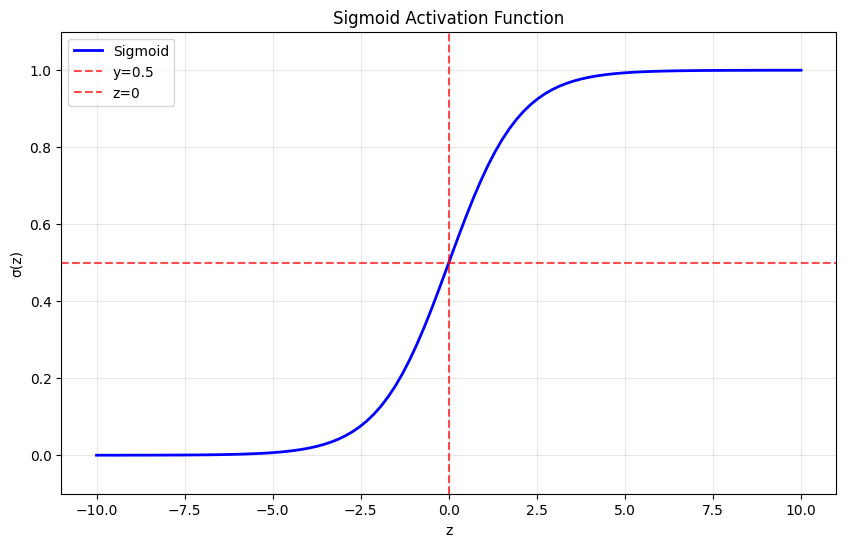

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

z = np.linspace(-10, 10, 100)
y = sigmoid(z)

plt.figure(figsize=(10, 6))
plt.plot(z, y, 'b-', linewidth=2, label='Sigmoid')
plt.grid(True, alpha=0.3)
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.title('Sigmoid Activation Function')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.7, label='y=0.5')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='z=0')
plt.legend()
plt.ylim(-0.1, 1.1)
plt.show()

##### 2.Tanh (Hyperbolic Tangent)

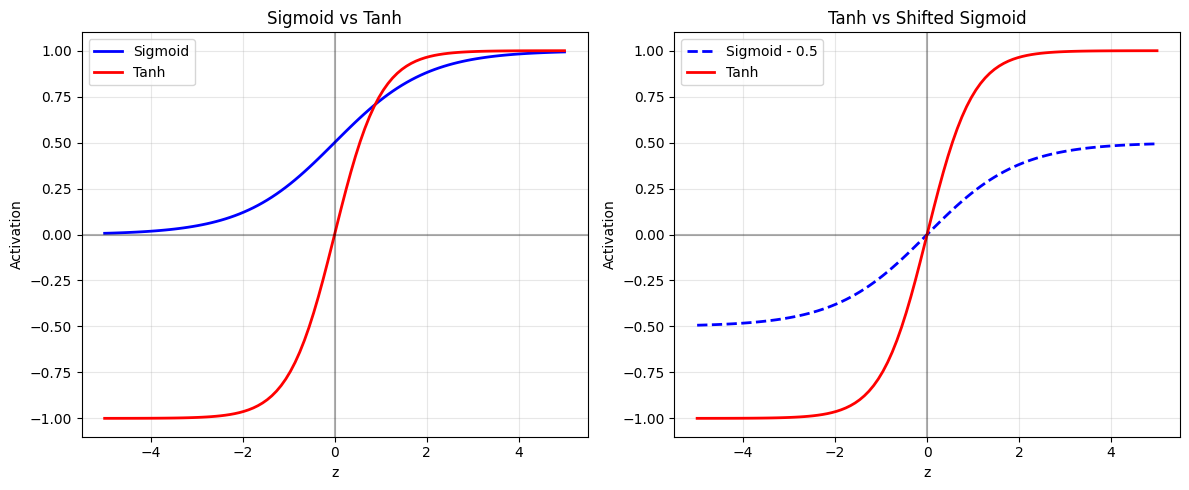

In [19]:
def tanh(z):
    return np.tanh(z)

z = np.linspace(-5, 5, 100)
sigmoid_vals = sigmoid(z)
tanh_vals = tanh(z)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(z, sigmoid_vals, 'b-', label='Sigmoid', linewidth=2)
plt.plot(z, tanh_vals, 'r-', label='Tanh', linewidth=2)
plt.grid(True, alpha=0.3)
plt.xlabel('z')
plt.ylabel('Activation')
plt.title('Sigmoid vs Tanh')
plt.legend()
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(z, sigmoid_vals - 0.5, 'b--', label='Sigmoid - 0.5', linewidth=2)
plt.plot(z, tanh_vals, 'r-', label='Tanh', linewidth=2)
plt.grid(True, alpha=0.3)
plt.xlabel('z')
plt.ylabel('Activation')
plt.title('Tanh vs Shifted Sigmoid')
plt.legend()
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

##### 3. ReLU (Rectified Linear Unit)

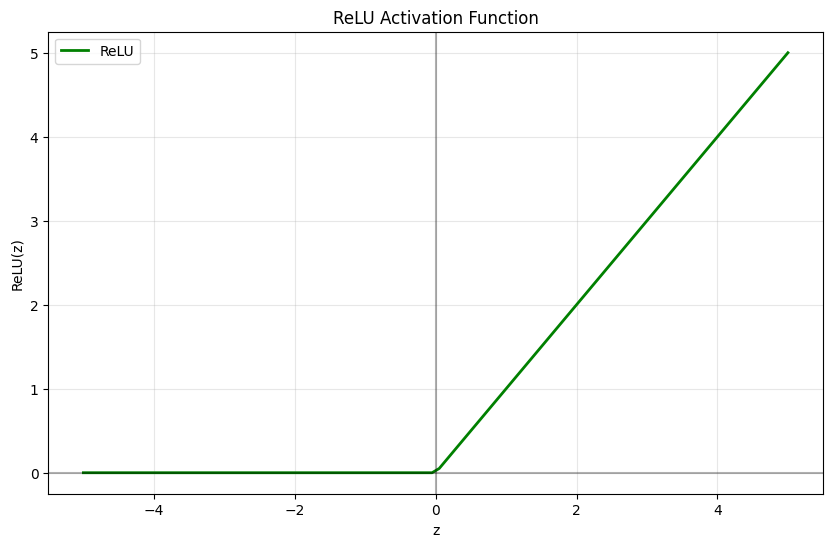

In [20]:
def relu(z):
    return np.maximum(0, z)

z = np.linspace(-5, 5, 100)
relu_vals = relu(z)

plt.figure(figsize=(10, 6))
plt.plot(z, relu_vals, 'g-', linewidth=2, label='ReLU')
plt.grid(True, alpha=0.3)
plt.xlabel('z')
plt.ylabel('ReLU(z)')
plt.title('ReLU Activation Function')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.legend()
plt.show()

##### 4. Leaky ReLU

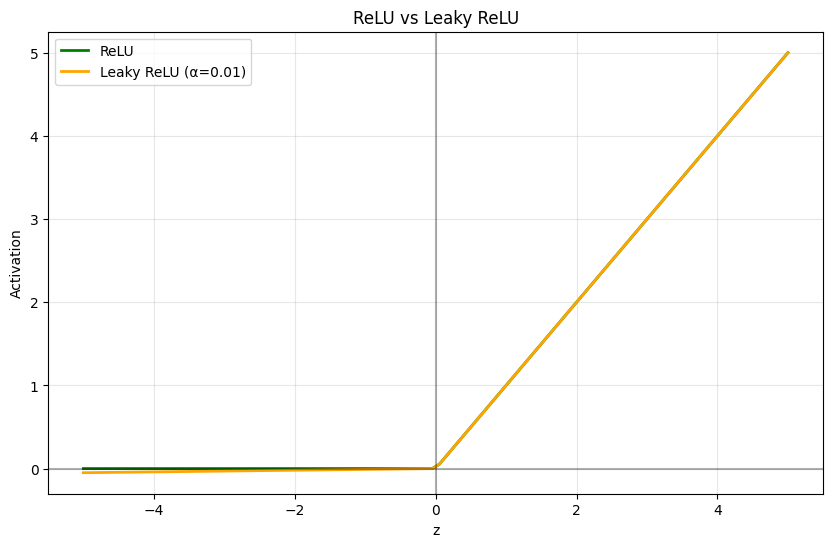

In [21]:
def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

z = np.linspace(-5, 5, 100)
relu_vals = relu(z)
leaky_relu_vals = leaky_relu(z, alpha=0.01)

plt.figure(figsize=(10, 6))
plt.plot(z, relu_vals, 'g-', linewidth=2, label='ReLU')
plt.plot(z, leaky_relu_vals, 'orange', linewidth=2, label='Leaky ReLU (α=0.01)')
plt.grid(True, alpha=0.3)
plt.xlabel('z')
plt.ylabel('Activation')
plt.title('ReLU vs Leaky ReLU')
plt.legend()
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.show()

##### Visual comparison

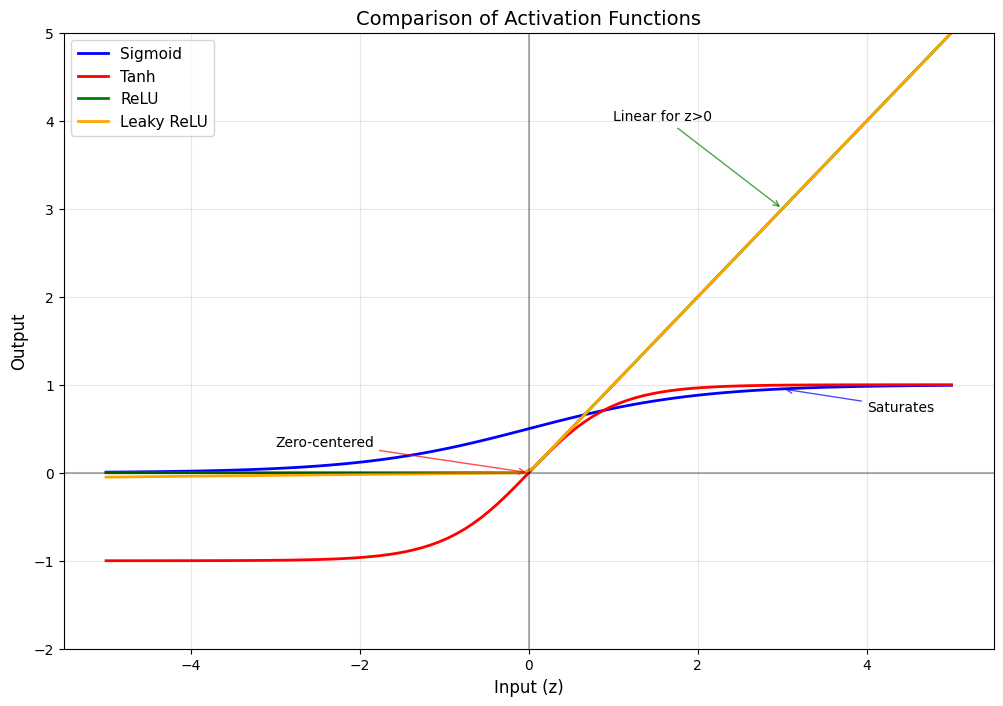

In [22]:
def plot_all_activations():
    """Compare all activation functions on the same plot"""
    z = np.linspace(-5, 5, 100)

    plt.figure(figsize=(12, 8))

    # All activation functions
    plt.plot(z, sigmoid(z), 'b-', linewidth=2, label='Sigmoid')
    plt.plot(z, tanh(z), 'r-', linewidth=2, label='Tanh')
    plt.plot(z, relu(z), 'g-', linewidth=2, label='ReLU')
    plt.plot(z, leaky_relu(z), 'orange', linewidth=2, label='Leaky ReLU')

    plt.grid(True, alpha=0.3)
    plt.xlabel('Input (z)', fontsize=12)
    plt.ylabel('Output', fontsize=12)
    plt.title('Comparison of Activation Functions', fontsize=14)
    plt.legend(fontsize=11)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

    # Add annotations
    plt.annotate('Saturates', xy=(3, sigmoid(3)), xytext=(4, 0.7),
                arrowprops=dict(arrowstyle='->', color='blue', alpha=0.7))
    plt.annotate('Zero-centered', xy=(0, tanh(0)), xytext=(-3, 0.3),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.7))
    plt.annotate('Linear for z>0', xy=(3, relu(3)), xytext=(1, 4),
                arrowprops=dict(arrowstyle='->', color='green', alpha=0.7))

    plt.ylim(-2, 5)
    plt.show()

plot_all_activations()

#### Implementation and Numerical Considerations

##### 1. Sigmoid Implementation with Numerical Stability

In [23]:
def stable_sigmoid(z):
    """
    Numerically stable sigmoid implementation
    """
    # Clip to prevent overflow
    z = np.clip(z, -500, 500)

    # Use different formulations for positive and negative z
    positive_mask = z>=0
    negative_mask = ~positive_mask

    result = np.zeros_like(z)

    # For positive z: σ(z) = 1 / (1 + e^(-z))
    result[positive_mask] = 1 / (1 + np.exp(-z[positive_mask]))

    # For negative z: σ(z) = e^z / (1 + e^z)
    exp_z = np.exp(z[negative_mask])
    result[negative_mask] = exp_z / (1 + exp_z)

    return result

# Test numerical stability
z_test = np.array([-1000, -100, -10, 0, 10, 100, 1000])
print("Regular sigmoid:")
print(sigmoid(z_test))
print("Stable sigmoid:")
print(stable_sigmoid(z_test))

Regular sigmoid:
[7.12457641e-218 3.72007598e-044 4.53978687e-005 5.00000000e-001
 9.99954602e-001 1.00000000e+000 1.00000000e+000]
Stable sigmoid:
[0 0 0 0 0 1 1]


##### 2. ReLU Variants Implementation

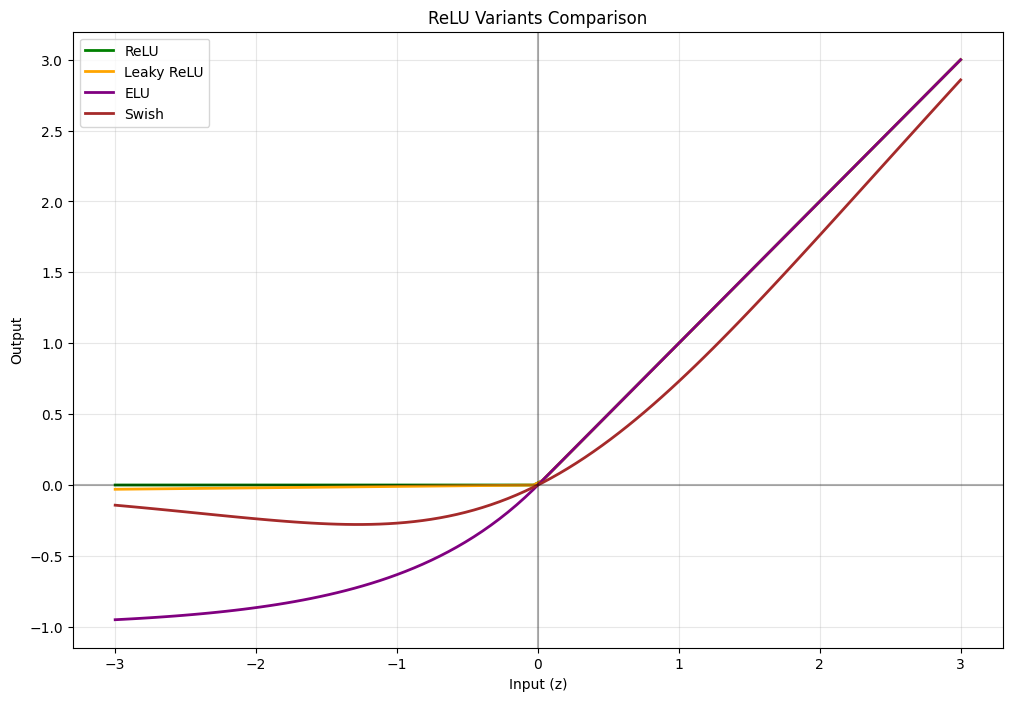

In [24]:
class ActivationFunctions:
    """Collection of activation functions with proper implementations"""

    @staticmethod
    def relu(z):
        """Standard ReLU"""
        return np.maximum(0, z)

    @staticmethod
    def leaky_relu(z, alpha=0.01):
        """Leaky ReLU with customizable slope"""
        return np.where(z > 0, z, alpha * z)

    @staticmethod
    def elu(z, alpha=1.0):
        """Exponential Linear Unit"""
        return np.where(z > 0, z, alpha * (np.exp(z) - 1))

    @staticmethod
    def swish(z):
        """Swish activation function (z * sigmoid(z))"""
        return z * stable_sigmoid(z)

    def compare_relu_variants(self, z_range=(-3, 3)):
        """Compare different ReLU variants"""
        z = np.linspace(z_range[0], z_range[1], 100)

        plt.figure(figsize=(12, 8))

        plt.plot(z, self.relu(z), 'g-', linewidth=2, label='ReLU')
        plt.plot(z, self.leaky_relu(z), 'orange', linewidth=2, label='Leaky ReLU')
        plt.plot(z, self.elu(z), 'purple', linewidth=2, label='ELU')
        plt.plot(z, self.swish(z), 'brown', linewidth=2, label='Swish')

        plt.grid(True, alpha=0.3)
        plt.xlabel('Input (z)')
        plt.ylabel('Output')
        plt.title('ReLU Variants Comparison')
        plt.legend()
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
        plt.show()

# Usage
activations = ActivationFunctions()
activations.compare_relu_variants()

##### 3. Activation Function with Caching

In [25]:
class ActivationLayer:
    """Activation layer with forward pass and caching for backpropagation"""

    def __init__(self, activation_type='relu'):
        self.activation_type = activation_type
        self.cache = {}

    def forward(self, z):
        """Forward pass through activation function"""
        if self.activation_type == 'sigmoid':
            a = stable_sigmoid(z)
        elif self.activation_type == 'tanh':
            a = np.tanh(z)
        elif self.activation_type == 'relu':
            a = np.maximum(0, z)
        elif self.activation_type == 'leaky_relu':
            a = np.where(z > 0, z, 0.01 * z)
        else:
            raise ValueError(f"Unknown activation: {self.activation_type}")

        # Cache for backpropagation
        self.cache['z'] = z
        self.cache['a'] = a

        return a

    def get_derivative(self, z=None):
        """Get derivative of activation function"""
        if z is None:
            z = self.cache['z']

        if self.activation_type == 'sigmoid':
            a = stable_sigmoid(z)
            return a * (1 - a)
        elif self.activation_type == 'tanh':
            return 1 - np.tanh(z)**2
        elif self.activation_type == 'relu':
            return (z > 0).astype(float)
        elif self.activation_type == 'leaky_relu':
            return np.where(z > 0, 1, 0.01)
        else:
            raise ValueError(f"Unknown activation: {self.activation_type}")

# Example usage
hidden_activation = ActivationLayer('relu')
output_activation = ActivationLayer('sigmoid')

# Forward pass
z1 = np.array([[0.5, -0.2], [1.3, -0.8]])
a1 = hidden_activation.forward(z1)
print("Hidden layer output:")
print(a1)

z2 = np.array([[0.3, -0.1]])
a2 = output_activation.forward(z2)
print("Output layer output:")
print(a2)

Hidden layer output:
[[0.5 0. ]
 [1.3 0. ]]
Output layer output:
[[0.57444252 0.47502081]]


#### Advanced Activation Functions

##### 1. **Swish Activation**

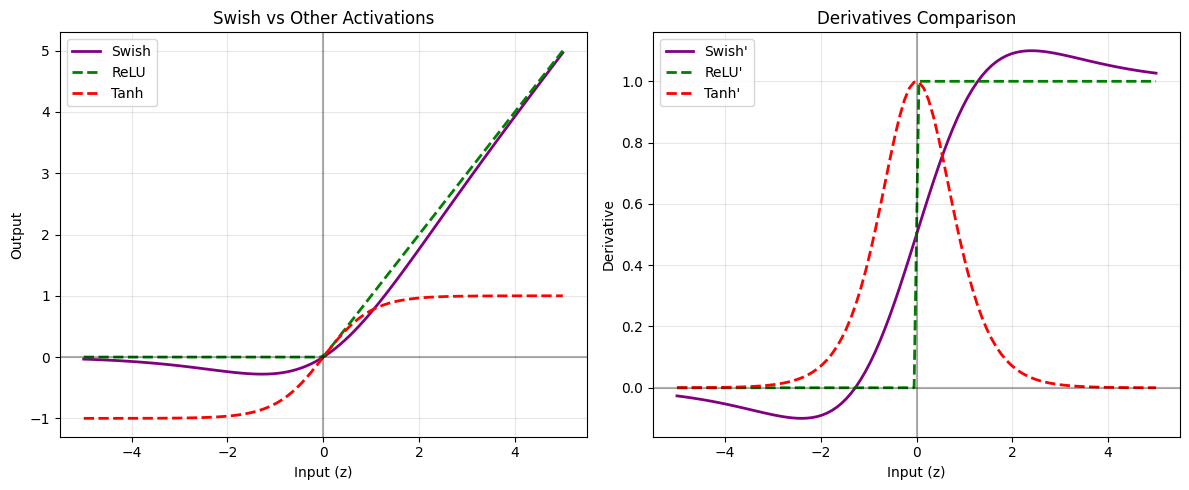

Swish Properties:
- Smooth and differentiable everywhere
- Non-monotonic (can decrease for negative inputs)
- Self-gated (uses its own values to gate)
- Often outperforms ReLU in deep networks


In [26]:
def swish_analysis():
    """
    Analysis of Swish activation function: f(x) = x * sigmoid(x)
    """

    def swish(z):
        return z * stable_sigmoid(z)

    def swish_derivative(z):
        """Derivative of swish function"""
        s = stable_sigmoid(z)
        return s + z * s * (1 - s)

    z = np.linspace(-5, 5, 100)

    plt.figure(figsize=(12, 5))

    # Function comparison
    plt.subplot(1, 2, 1)
    plt.plot(z, swish(z), 'purple', linewidth=2, label='Swish')
    plt.plot(z, np.maximum(0, z), 'g--', linewidth=2, label='ReLU')
    plt.plot(z, np.tanh(z), 'r--', linewidth=2, label='Tanh')
    plt.grid(True, alpha=0.3)
    plt.xlabel('Input (z)')
    plt.ylabel('Output')
    plt.title('Swish vs Other Activations')
    plt.legend()
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

    # Derivative comparison
    plt.subplot(1, 2, 2)
    plt.plot(z, swish_derivative(z), 'purple', linewidth=2, label="Swish'")
    plt.plot(z, (z > 0).astype(float), 'g--', linewidth=2, label="ReLU'")
    plt.plot(z, 1 - np.tanh(z)**2, 'r--', linewidth=2, label="Tanh'")
    plt.grid(True, alpha=0.3)
    plt.xlabel('Input (z)')
    plt.ylabel('Derivative')
    plt.title('Derivatives Comparison')
    plt.legend()
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("Swish Properties:")
    print("- Smooth and differentiable everywhere")
    print("- Non-monotonic (can decrease for negative inputs)")
    print("- Self-gated (uses its own values to gate)")
    print("- Often outperforms ReLU in deep networks")

swish_analysis()

##### 2. **GELU (Gaussian Error Linear Unit)**

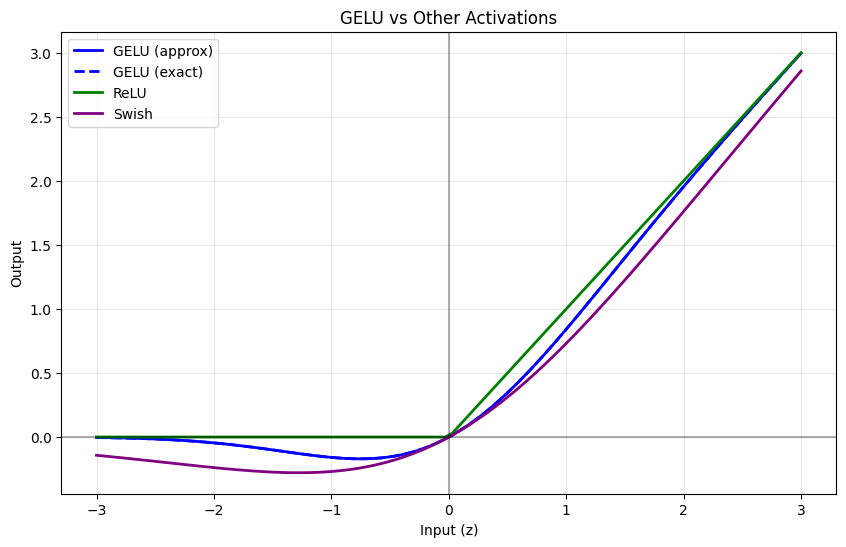

GELU Properties:
- Smooth approximation to ReLU
- Probabilistically motivated
- Used in BERT and other transformer models
- Better than ReLU for some applications


In [27]:
def gelu_analysis():
    """
    Analysis of GELU activation function
    """

    def gelu_approx(z):
        """Approximation: GELU(x) ≈ 0.5x(1 + tanh(√(2/π)(x + 0.044715x³)))"""
        return 0.5 * z * (1 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3)))

    def gelu_exact(z):
        """Exact: GELU(x) = x * Φ(x) where Φ is CDF of standard normal"""
        from scipy.stats import norm
        return z * norm.cdf(z)

    def swish(z):
        return z * stable_sigmoid(z)

    z = np.linspace(-3, 3, 100)

    try:
        plt.figure(figsize=(10, 6))
        plt.plot(z, gelu_approx(z), 'b-', linewidth=2, label='GELU (approx)')
        plt.plot(z, gelu_exact(z), 'b--', linewidth=2, label='GELU (exact)')
        plt.plot(z, np.maximum(0, z), 'g-', linewidth=2, label='ReLU')
        plt.plot(z, swish(z), 'purple', linewidth=2, label='Swish')

        plt.grid(True, alpha=0.3)
        plt.xlabel('Input (z)')
        plt.ylabel('Output')
        plt.title('GELU vs Other Activations')
        plt.legend()
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
        plt.show()

    except ImportError:
        print("GELU analysis requires scipy. Using approximation only.")

        plt.figure(figsize=(10, 6))
        plt.plot(z, gelu_approx(z), 'b-', linewidth=2, label='GELU')
        plt.plot(z, np.maximum(0, z), 'g-', linewidth=2, label='ReLU')
        plt.grid(True, alpha=0.3)
        plt.xlabel('Input (z)')
        plt.ylabel('Output')
        plt.title('GELU vs ReLU')
        plt.legend()
        plt.show()

    print("GELU Properties:")
    print("- Smooth approximation to ReLU")
    print("- Probabilistically motivated")
    print("- Used in BERT and other transformer models")
    print("- Better than ReLU for some applications")

gelu_analysis()

#### Production-Ready Activation Module (Not that important for now)

In [28]:
class ActivationModule:
    """
    Production-ready activation function module
    """

    def __init__(self):
        self.supported_functions = [
            'relu', 'leaky_relu', 'sigmoid', 'tanh',
            'swish', 'gelu', 'linear'
        ]

    def __call__(self, z, activation_type='relu', **kwargs):
        """
        Apply activation function with error handling
        """
        if activation_type not in self.supported_functions:
            raise ValueError(f"Unsupported activation: {activation_type}")

        # Input validation
        if not isinstance(z, np.ndarray):
            z = np.array(z)

        # Check for invalid inputs
        if np.any(np.isnan(z)):
            raise ValueError("Input contains NaN values")

        if np.any(np.isinf(z)):
            print("Warning: Input contains infinite values")

        # Apply activation
        if activation_type == 'relu':
            return self._relu(z)
        elif activation_type == 'leaky_relu':
            alpha = kwargs.get('alpha', 0.01)
            return self._leaky_relu(z, alpha)
        elif activation_type == 'sigmoid':
            return self._stable_sigmoid(z)
        elif activation_type == 'tanh':
            return self._tanh(z)
        elif activation_type == 'swish':
            return self._swish(z)
        elif activation_type == 'gelu':
            return self._gelu(z)
        elif activation_type == 'linear':
            return z

    def _relu(self, z):
        """ReLU with gradient checking"""
        result = np.maximum(0, z)

        # Check for dying ReLU
        if np.mean(result == 0) > 0.5:
            print("Warning: >50% of ReLU outputs are zero (dying ReLU)")

        return result

    def _leaky_relu(self, z, alpha=0.01):
        """Leaky ReLU with parameter validation"""
        if alpha <= 0 or alpha >= 1:
            raise ValueError("Alpha must be in (0, 1)")

        return np.where(z > 0, z, alpha * z)

    def _stable_sigmoid(self, z):
        """Numerically stable sigmoid"""
        # Clip extreme values
        z = np.clip(z, -500, 500)

        # Check for saturation
        saturated = np.sum((z < -10) | (z > 10))
        if saturated > 0:
            print(f"Warning: {saturated} sigmoid inputs are saturated")

        return 1 / (1 + np.exp(-z))

    def _tanh(self, z):
        """Tanh with saturation warning"""
        result = np.tanh(z)

        # Check for saturation
        saturated = np.sum((np.abs(result) > 0.99))
        if saturated > 0:
            print(f"Warning: {saturated} tanh outputs are saturated")

        return result

    def _swish(self, z):
        """Swish activation"""
        return z * self._stable_sigmoid(z)

    def _gelu(self, z):
        """GELU approximation"""
        return 0.5 * z * (1 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3)))

    def get_derivative(self, z, activation_type='relu', **kwargs):
        """Get derivative of activation function"""
        if activation_type == 'relu':
            return (z > 0).astype(float)
        elif activation_type == 'leaky_relu':
            alpha = kwargs.get('alpha', 0.01)
            return np.where(z > 0, 1, alpha)
        elif activation_type == 'sigmoid':
            s = self._stable_sigmoid(z)
            return s * (1 - s)
        elif activation_type == 'tanh':
            return 1 - np.tanh(z)**2
        elif activation_type == 'linear':
            return np.ones_like(z)
        else:
            raise NotImplementedError(f"Derivative for {activation_type} not implemented")

# Example usage
activation_module = ActivationModule()

# Test with sample data
z_test = np.array([[-2, -1, 0, 1, 2], [0.5, -0.5, 3, -3, 0]])

print("Testing Production Activation Module:")
print("=" * 45)

for activation_type in ['relu', 'sigmoid', 'tanh']:
    result = activation_module(z_test, activation_type)
    print(f"{activation_type.upper()}:")
    print(f"  Input:  {z_test}")
    print(f"  Output: {result}")
    print()

Testing Production Activation Module:
RELU:
  Input:  [[-2.  -1.   0.   1.   2. ]
 [ 0.5 -0.5  3.  -3.   0. ]]
  Output: [[0.  0.  0.  1.  2. ]
 [0.5 0.  3.  0.  0. ]]

SIGMOID:
  Input:  [[-2.  -1.   0.   1.   2. ]
 [ 0.5 -0.5  3.  -3.   0. ]]
  Output: [[0.11920292 0.26894142 0.5        0.73105858 0.88079708]
 [0.62245933 0.37754067 0.95257413 0.04742587 0.5       ]]

TANH:
  Input:  [[-2.  -1.   0.   1.   2. ]
 [ 0.5 -0.5  3.  -3.   0. ]]
  Output: [[-0.96402758 -0.76159416  0.          0.76159416  0.96402758]
 [ 0.46211716 -0.46211716  0.99505475 -0.99505475  0.        ]]



#### Hands-On: Testing and Visualizing Activation Function Derivatives

##### What We're Doing

In this notebook, we'll **verify our mathematical understanding** of activation function derivatives through code. This is crucial because:

- **Derivatives control learning** - they determine how gradients flow through your network
- **Implementation bugs are common** - numerical checking catches formula mistakes
- **Visual understanding helps** - seeing the curves makes the math intuitive

##### Why This Matters

When you implement neural networks from scratch or debug training problems, you need to:
1. **Verify your derivative formulas** are mathematically correct
2. **Understand gradient flow** through different activation functions  
3. **Recognize vanishing/exploding gradient problems** visually
4. **Choose the right activation** based on derivative properties

##### What You'll Learn

By the end of this section, you'll be able to:
- ✅ **Test any activation derivative** using numerical approximation
- ✅ **Visualize activation functions** and their derivatives side-by-side
- ✅ **Simulate gradient flow** through deep networks
- ✅ **Identify problematic activations** that cause training issues

##### The Big Picture

This connects directly to why **ReLU revolutionized deep learning**:
- Sigmoid/Tanh: derivatives vanish → gradients die → deep networks fail
- ReLU: derivative = 1 → gradients preserved → deep networks succeed

Let's see this in action! 👇

###### 1. Define Our Activation Functions
Let's start by defining the basic functions we'll be testing:

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def numerical_derivative(func, z, epsilon=1e-7):
    """Compute numerical derivative using finite differences"""
    return (func(z + epsilon) - func(z - epsilon)) / (2 * epsilon)

# Test a single point to make sure everything works
z_test = 1.0
print("🧪 Quick Test:")
print(f"z = {z_test}")
print(f"Sigmoid: {sigmoid(z_test):.6f}")
print(f"Analytical derivative: {sigmoid(z_test) * (1 - sigmoid(z_test)):.6f}")
print(f"Numerical derivative: {numerical_derivative(sigmoid, z_test):.6f}")

🧪 Quick Test:
z = 1.0
Sigmoid: 0.731059
Analytical derivative: 0.196612
Numerical derivative: 0.196612


##### 2. Test All Activation Derivatives
Now let's systematically test all our derivatives:

In [30]:
def test_activation_derivatives():
    """Test derivatives for all major activation functions"""
    
    print("🧪 TESTING ALL ACTIVATION DERIVATIVES")
    print("=" * 50)
    
    # Test points - include edge cases
    test_points = [-3, -1, -0.5, 0, 0.5, 1, 3]
    
    # Define our functions and derivatives
    functions = {
        'sigmoid': {
            'func': lambda z: sigmoid(z),
            'derivative': lambda z: sigmoid(z) * (1 - sigmoid(z))
        },
        'tanh': {
            'func': lambda z: np.tanh(z),
            'derivative': lambda z: 1 - np.tanh(z)**2
        },
        'relu': {
            'func': lambda z: np.maximum(0, z),
            'derivative': lambda z: np.where(z > 0, 1.0, 0.0)
        }
    }
    
    for name, funcs in functions.items():
        print(f"\n📊 {name.upper()} DERIVATIVE TEST:")
        print("z     | Analytical | Numerical  | Difference | Status")
        print("------|------------|------------|------------|--------")
        
        for z in test_points:
            # Handle ReLU special case at z=0
            if name == 'relu' and z == 0:
                print(f"{z:5.1f} | {'N/A':>10} | {'N/A':>10} | {'N/A':>10} | ⚠️ Not differentiable")
                continue
                
            analytical = funcs['derivative'](z)
            numerical = numerical_derivative(funcs['func'], z)
            diff = abs(analytical - numerical)
            
            status = "✅ PASS" if diff < 1e-6 else "❌ FAIL"
            print(f"{z:5.1f} | {analytical:10.6f} | {numerical:10.6f} | {diff:.2e} | {status}")

# Run the test
test_activation_derivatives()

🧪 TESTING ALL ACTIVATION DERIVATIVES

📊 SIGMOID DERIVATIVE TEST:
z     | Analytical | Numerical  | Difference | Status
------|------------|------------|------------|--------
 -3.0 |   0.045177 |   0.045177 | 6.08e-11 | ✅ PASS
 -1.0 |   0.196612 |   0.196612 | 1.59e-10 | ✅ PASS
 -0.5 |   0.235004 |   0.235004 | 1.56e-10 | ✅ PASS
  0.0 |   0.250000 |   0.250000 | 6.87e-10 | ✅ PASS
  0.5 |   0.235004 |   0.235004 | 1.56e-10 | ✅ PASS
  1.0 |   0.196612 |   0.196612 | 3.96e-10 | ✅ PASS
  3.0 |   0.045177 |   0.045177 | 4.60e-10 | ✅ PASS

📊 TANH DERIVATIVE TEST:
z     | Analytical | Numerical  | Difference | Status
------|------------|------------|------------|--------
 -3.0 |   0.009866 |   0.009866 | 2.89e-10 | ✅ PASS
 -1.0 |   0.419974 |   0.419974 | 1.99e-10 | ✅ PASS
 -0.5 |   0.786448 |   0.786448 | 1.96e-10 | ✅ PASS
  0.0 |   1.000000 |   1.000000 | 3.33e-15 | ✅ PASS
  0.5 |   0.786448 |   0.786448 | 1.96e-10 | ✅ PASS
  1.0 |   0.419974 |   0.419974 | 1.99e-10 | ✅ PASS
  3.0 |   0.0098

##### 3. Visualize the Functions and Their Derivatives
Seeing the curves helps build intuition:

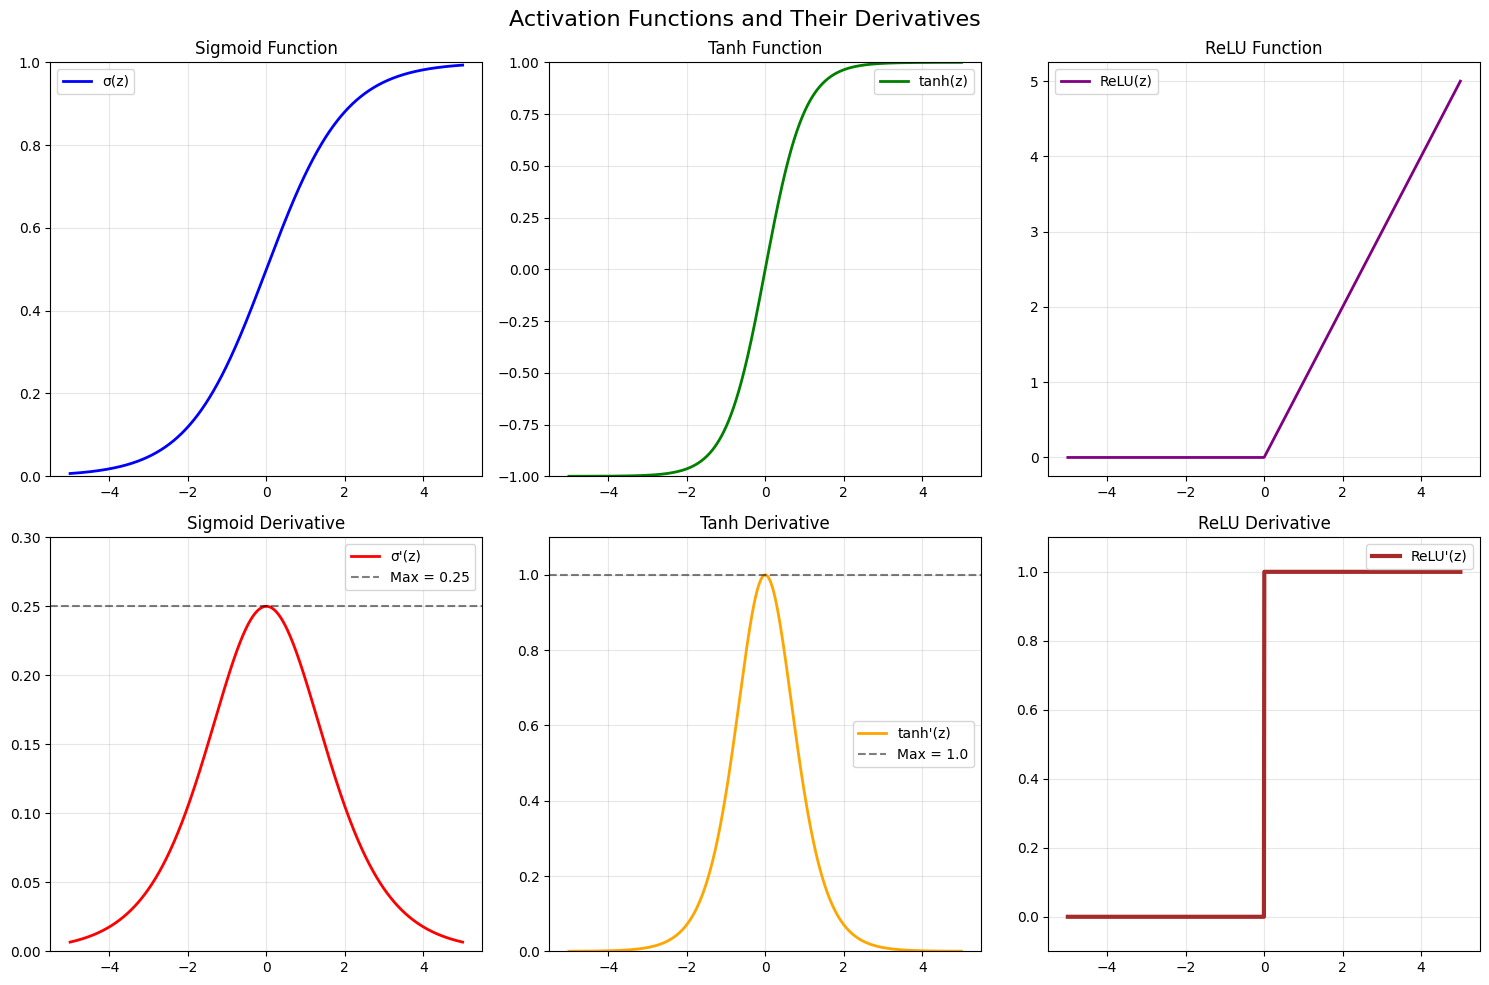

📊 Key Observations:
• Sigmoid derivative peaks at 0.25 and vanishes for large |z|
• Tanh derivative peaks at 1.0 (4x better than sigmoid)
• ReLU derivative is constant 1 for positive inputs


In [31]:
def plot_activations_and_derivatives():
    """Create side-by-side plots of functions and derivatives"""
    
    z = np.linspace(-5, 5, 1000)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Activation Functions and Their Derivatives', fontsize=16)
    
    # Sigmoid
    sigmoid_vals = sigmoid(z)
    sigmoid_derivs = sigmoid_vals * (1 - sigmoid_vals)
    
    axes[0,0].plot(z, sigmoid_vals, 'b-', linewidth=2, label='σ(z)')
    axes[0,0].set_title('Sigmoid Function')
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].legend()
    axes[0,0].set_ylim(0, 1)
    
    axes[1,0].plot(z, sigmoid_derivs, 'r-', linewidth=2, label="σ'(z)")
    axes[1,0].set_title('Sigmoid Derivative')
    axes[1,0].grid(True, alpha=0.3)
    axes[1,0].axhline(y=0.25, color='k', linestyle='--', alpha=0.5, label='Max = 0.25')
    axes[1,0].legend()
    axes[1,0].set_ylim(0, 0.3)
    
    # Tanh
    tanh_vals = np.tanh(z)
    tanh_derivs = 1 - tanh_vals**2
    
    axes[0,1].plot(z, tanh_vals, 'g-', linewidth=2, label='tanh(z)')
    axes[0,1].set_title('Tanh Function')
    axes[0,1].grid(True, alpha=0.3)
    axes[0,1].legend()
    axes[0,1].set_ylim(-1, 1)
    
    axes[1,1].plot(z, tanh_derivs, 'orange', linewidth=2, label="tanh'(z)")
    axes[1,1].set_title('Tanh Derivative')
    axes[1,1].grid(True, alpha=0.3)
    axes[1,1].axhline(y=1.0, color='k', linestyle='--', alpha=0.5, label='Max = 1.0')
    axes[1,1].legend()
    axes[1,1].set_ylim(0, 1.1)
    
    # ReLU
    relu_vals = np.maximum(0, z)
    relu_derivs = np.where(z > 0, 1.0, 0.0)
    
    axes[0,2].plot(z, relu_vals, 'purple', linewidth=2, label='ReLU(z)')
    axes[0,2].set_title('ReLU Function')
    axes[0,2].grid(True, alpha=0.3)
    axes[0,2].legend()
    
    axes[1,2].plot(z, relu_derivs, 'brown', linewidth=3, label="ReLU'(z)")
    axes[1,2].set_title('ReLU Derivative')
    axes[1,2].grid(True, alpha=0.3)
    axes[1,2].legend()
    axes[1,2].set_ylim(-0.1, 1.1)
    
    plt.tight_layout()
    plt.show()
    
    print("📊 Key Observations:")
    print("• Sigmoid derivative peaks at 0.25 and vanishes for large |z|")
    print("• Tanh derivative peaks at 1.0 (4x better than sigmoid)")
    print("• ReLU derivative is constant 1 for positive inputs")

# Create the visualization
plot_activations_and_derivatives()

##### 4. Simulate Gradient Flow Through Deep Networks
This shows why activation choice matters for deep learning:

In [32]:
def simulate_gradient_flow():
    """Show how gradients flow through deep networks"""
    
    print("🌊 GRADIENT FLOW SIMULATION")
    print("=" * 40)
    print("Simulating gradient flow through a 10-layer network...\n")
    
    layers = 10
    initial_gradient = 1.0
    
    # Different scenarios
    scenarios = {
        'Sigmoid (worst case)': 0.25,  # Max derivative
        'Tanh (better)': 1.0,          # Max derivative
        'ReLU (best)': 1.0,            # Derivative for active neurons
        'Poor initialization': 0.1      # Simulating bad weights
    }
    
    results = {}
    
    for name, derivative_factor in scenarios.items():
        gradient = initial_gradient
        gradients = [gradient]
        
        # Simulate backward pass through layers
        for layer in range(layers - 1):
            gradient *= derivative_factor
            gradients.append(gradient)
        
        results[name] = gradients
        
        # Print results
        print(f"{name}:")
        print(f"  Input → Output: {initial_gradient:.6f} → {gradient:.2e}")
        print(f"  Final ratio: {gradient/initial_gradient:.2e}")
        
        # Classify the problem
        if gradient < 1e-6:
            print("  Status: ❌ SEVERE vanishing gradients")
        elif gradient < 1e-3:
            print("  Status: ⚠️ Vanishing gradients")
        elif gradient > 1e3:
            print("  Status: ❌ Exploding gradients")
        else:
            print("  Status: ✅ Stable gradients")
        print()
    
    return results

# Run simulation
gradient_results = simulate_gradient_flow()

🌊 GRADIENT FLOW SIMULATION
Simulating gradient flow through a 10-layer network...

Sigmoid (worst case):
  Input → Output: 1.000000 → 3.81e-06
  Final ratio: 3.81e-06
  Status: ⚠️ Vanishing gradients

Tanh (better):
  Input → Output: 1.000000 → 1.00e+00
  Final ratio: 1.00e+00
  Status: ✅ Stable gradients

ReLU (best):
  Input → Output: 1.000000 → 1.00e+00
  Final ratio: 1.00e+00
  Status: ✅ Stable gradients

Poor initialization:
  Input → Output: 1.000000 → 1.00e-09
  Final ratio: 1.00e-09
  Status: ❌ SEVERE vanishing gradients



##### 5. Visualize the Gradient Flow Problem
Let's plot how gradients change as they flow backward:

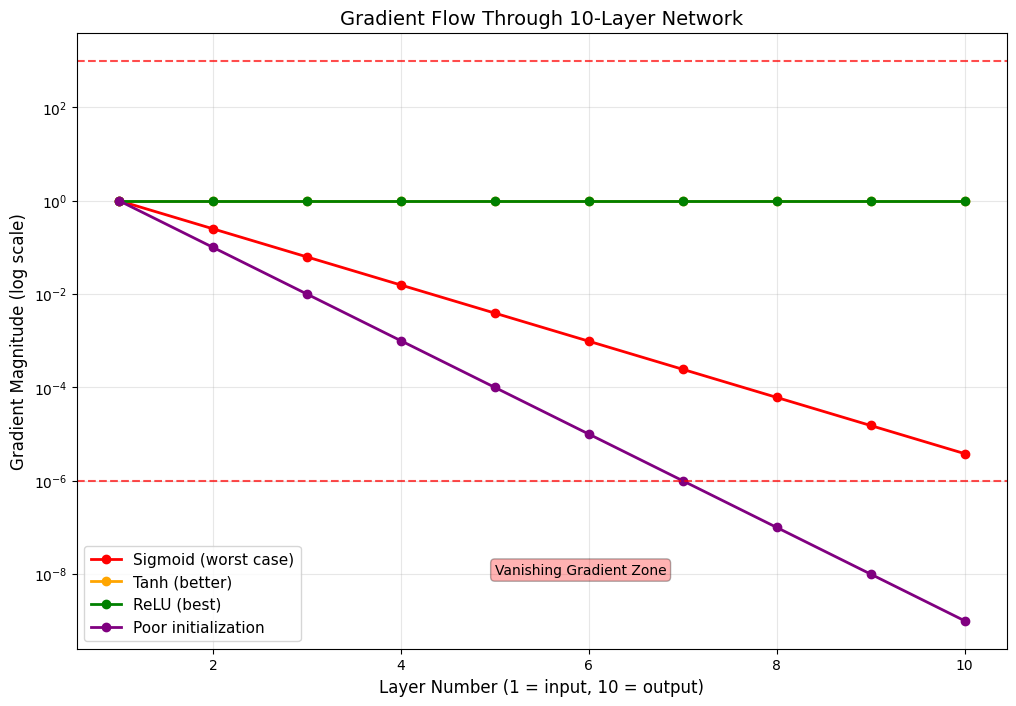

🎯 This is why ReLU revolutionized deep learning!
• Sigmoid: gradients vanish exponentially
• ReLU: gradients stay constant (when active)


In [33]:
def plot_gradient_flow(results):
    """Plot gradient flow visualization"""
    
    plt.figure(figsize=(12, 8))
    
    colors = ['red', 'orange', 'green', 'purple']
    
    for i, (name, gradients) in enumerate(gradient_results.items()):
        layer_nums = list(range(1, len(gradients) + 1))
        plt.semilogy(layer_nums, np.abs(gradients), 'o-', 
                    linewidth=2, markersize=6, label=name, color=colors[i])
    
    plt.xlabel('Layer Number (1 = input, 10 = output)', fontsize=12)
    plt.ylabel('Gradient Magnitude (log scale)', fontsize=12)
    plt.title('Gradient Flow Through 10-Layer Network', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    # Add problem zone indicators
    plt.axhline(y=1e-6, color='red', linestyle='--', alpha=0.7, 
                label='Vanishing threshold')
    plt.axhline(y=1e3, color='red', linestyle='--', alpha=0.7, 
                label='Exploding threshold')
    
    # Add annotations
    plt.annotate('Vanishing Gradient Zone', xy=(5, 1e-8), fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="red", alpha=0.3))
    
    plt.show()
    
    print("🎯 This is why ReLU revolutionized deep learning!")
    print("• Sigmoid: gradients vanish exponentially")
    print("• ReLU: gradients stay constant (when active)")

# Plot the results
plot_gradient_flow(gradient_results)

##### 6. Explore Specific Points
Let's examine activation values and derivatives at key points:

In [34]:
def explore_activation_points():
    """Explore derivatives at interesting points"""
    
    print("🔍 ACTIVATION FUNCTION EXPLORER")
    print("=" * 40)
    
    # Key points to examine
    points_of_interest = {
        -5: "Large negative",
        -1: "Moderate negative", 
        0: "Zero point",
        1: "Moderate positive",
        5: "Large positive"
    }
    
    for z_val, description in points_of_interest.items():
        print(f"\n📍 z = {z_val} ({description})")
        print("-" * 30)
        
        # Sigmoid
        s = sigmoid(z_val)
        s_deriv = s * (1 - s)
        print(f"Sigmoid:     f({z_val}) = {s:.4f}, f'({z_val}) = {s_deriv:.6f}")
        
        # Tanh
        t = np.tanh(z_val)
        t_deriv = 1 - t**2
        print(f"Tanh:        f({z_val}) = {t:.4f}, f'({z_val}) = {t_deriv:.6f}")
        
        # ReLU
        r = max(0, z_val)
        r_deriv = 1 if z_val > 0 else 0
        print(f"ReLU:        f({z_val}) = {r:.4f}, f'({z_val}) = {r_deriv:.6f}")
        
        # Leaky ReLU
        alpha = 0.01
        lr = max(alpha * z_val, z_val)
        lr_deriv = 1 if z_val > 0 else alpha
        print(f"Leaky ReLU:  f({z_val}) = {lr:.4f}, f'({z_val}) = {lr_deriv:.6f}")

# Explore the points
explore_activation_points()

print("\n🎉 ANALYSIS COMPLETE!")
print("\n💡 Key Takeaways:")
print("• ReLU derivatives don't vanish (constant 1 for z>0)")
print("• Sigmoid/Tanh derivatives approach 0 for large |z|")
print("• Numerical checking verifies our analytical formulas")
print("• Gradient flow determines if deep networks can train")

🔍 ACTIVATION FUNCTION EXPLORER

📍 z = -5 (Large negative)
------------------------------
Sigmoid:     f(-5) = 0.0067, f'(-5) = 0.006648
Tanh:        f(-5) = -0.9999, f'(-5) = 0.000182
ReLU:        f(-5) = 0.0000, f'(-5) = 0.000000
Leaky ReLU:  f(-5) = -0.0500, f'(-5) = 0.010000

📍 z = -1 (Moderate negative)
------------------------------
Sigmoid:     f(-1) = 0.2689, f'(-1) = 0.196612
Tanh:        f(-1) = -0.7616, f'(-1) = 0.419974
ReLU:        f(-1) = 0.0000, f'(-1) = 0.000000
Leaky ReLU:  f(-1) = -0.0100, f'(-1) = 0.010000

📍 z = 0 (Zero point)
------------------------------
Sigmoid:     f(0) = 0.5000, f'(0) = 0.250000
Tanh:        f(0) = 0.0000, f'(0) = 1.000000
ReLU:        f(0) = 0.0000, f'(0) = 0.000000
Leaky ReLU:  f(0) = 0.0000, f'(0) = 0.010000

📍 z = 1 (Moderate positive)
------------------------------
Sigmoid:     f(1) = 0.7311, f'(1) = 0.196612
Tanh:        f(1) = 0.7616, f'(1) = 0.419974
ReLU:        f(1) = 1.0000, f'(1) = 1.000000
Leaky ReLU:  f(1) = 1.0000, f'(1) = 1.0000

#### MAIN CODE

#### Activation Functions Implementation


ACTIVATION FUNCTIONS
z values: [-2 -1  0  1  2]
Sigmoid: [0.119 0.269 0.5   0.731 0.881]
Tanh:    [-0.964 -0.762  0.     0.762  0.964]
ReLU:    [0 0 0 1 2]


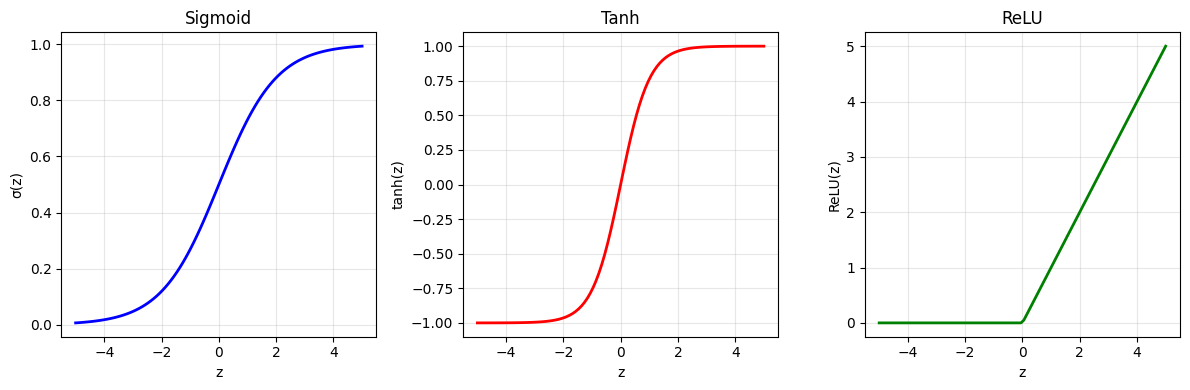

In [35]:
def activation_functions_demo():
    """
    Implement and visualize activation functions
    """
    print("\nACTIVATION FUNCTIONS")
    print("=" * 20)

    # Test inputs
    z = np.array([-2, -1, 0, 1, 2])

    # Sigmoid
    sigmoid = 1 / (1 + np.exp(-z))

    # Tanh
    tanh = np.tanh(z)

    # ReLU
    relu = np.maximum(0,z)

    # Display results
    print("z values:", z)
    print("Sigmoid:", sigmoid.round(3))
    print("Tanh:   ", tanh.round(3))
    print("ReLU:   ", relu)

    # Visualize
    z_plot = np.linspace(-5, 5, 100)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.plot(z_plot, 1/(1 + np.exp(-z_plot)), 'b-', linewidth=2)
    plt.title('Sigmoid')
    plt.grid(True, alpha=0.3)
    plt.xlabel('z')
    plt.ylabel('σ(z)')

    plt.subplot(1, 3, 2)
    plt.plot(z_plot, np.tanh(z_plot), 'r-', linewidth=2)
    plt.title('Tanh')
    plt.grid(True, alpha=0.3)
    plt.xlabel('z')
    plt.ylabel('tanh(z)')

    plt.subplot(1, 3, 3)
    plt.plot(z_plot, np.maximum(0, z_plot), 'g-', linewidth=2)
    plt.title('ReLU')
    plt.grid(True, alpha=0.3)
    plt.xlabel('z')
    plt.ylabel('ReLU(z)')

    plt.tight_layout()
    plt.show()

activation_functions_demo()

#### Activation Function Derivatives

In [36]:
def activation_derivatives():
    """
    Compute derivatives of activation functions (needed for backprop)
    """
    print("\nACTIVATION FUNCTION DERIVATIVES")
    print("=" * 35)

    z = np.array([-1, 0, 1])

    # Sigmoid derivative: g'(z) = g(z) * (1 - g(z))
    sigmoid_z = 1 / (1 + np.exp(-z))
    sigmoid_derivative = sigmoid_z * (1 - sigmoid_z)

    # Tanh derivative: g'(z) = 1 - (tanh(z))^2
    tanh_z = np.tanh(z)
    tanh_derivative = 1 - tanh_z**2

    # ReLU derivative: g'(z) = 1 if z > 0, else 0
    relu_derivative = (z > 0).astype(float)

    print("z values:        ", z)
    print("Sigmoid':        ", sigmoid_derivative.round(3))
    print("Tanh':           ", tanh_derivative.round(3))
    print("ReLU':           ", relu_derivative)

    print("\nKey insights:")
    print("• Sigmoid derivative max = 0.25 (at z=0)")
    print("• Tanh derivative max = 1.0 (at z=0)")
    print("• ReLU derivative = 1 for z>0, 0 for z<0")

activation_derivatives()


ACTIVATION FUNCTION DERIVATIVES
z values:         [-1  0  1]
Sigmoid':         [0.197 0.25  0.197]
Tanh':            [0.42 1.   0.42]
ReLU':            [0. 0. 1.]

Key insights:
• Sigmoid derivative max = 0.25 (at z=0)
• Tanh derivative max = 1.0 (at z=0)
• ReLU derivative = 1 for z>0, 0 for z<0


## 4. Backpropagation Implementation

#### Setup and Imports

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib for better plots
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

#### Numerical Derivative Calculation

Calculate derivatives numerically using the definition: $$derivative = (change in output) / (change in input)$$. This demonstrates what $$∂L/∂A²$$ actually means in practice - how much the loss changes when we slightly adjust our prediction.

In [38]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Loss function: L = -(y*log(A²) + (1-y)*log(1-A²))
# For y=1, this simplifies to: L = -log(A²)

y = 1
A2 = 0.8
loss = -1 * math.log(A2)  # ≈ 0.223

print("🧮 NUMERICAL DERIVATIVE DEMONSTRATION")
print("="*40)
print(f"Original prediction: A² = {A2}")
print(f"True label: y = {y}")
print(f"Original loss: L = -log({A2}) = {loss:.6f}")

🧮 NUMERICAL DERIVATIVE DEMONSTRATION
Original prediction: A² = 0.8
True label: y = 1
Original loss: L = -log(0.8) = 0.223144


In [39]:
# Now let's see what happens if we change A² slightly
A2_new = 0.81  # Increased by 0.01
loss_new = -1 * math.log(A2_new)  # ≈ 0.211

# The change in loss
change_in_loss = loss_new - loss  # ≈ -0.012
change_in_A2 = A2_new - A2       # = 0.01

# The derivative (rate of change)
derivative = change_in_loss / change_in_A2  # ≈ -1.2

print(f"After small change:")
print(f"New prediction: A² = {A2_new}")
print(f"New loss: L = -log({A2_new}) = {loss_new:.6f}")
print(f"Change in loss: ΔL = {change_in_loss:.6f}")
print(f"Change in A²: ΔA² = {change_in_A2:.6f}")
print(f"Numerical derivative: ΔL/ΔA² = {derivative:.3f}")

After small change:
New prediction: A² = 0.81
New loss: L = -log(0.81) = 0.210721
Change in loss: ΔL = -0.012423
Change in A²: ΔA² = 0.010000
Numerical derivative: ΔL/ΔA² = -1.242


In [40]:
# Compare with analytical derivative
analytical_derivative = -y/A2  # -1/0.8 = -1.25
print(f"Analytical derivative: ∂L/∂A² = -y/A² = -{y}/{A2} = {analytical_derivative:.3f}")
print(f"Difference: {abs(derivative - analytical_derivative):.3f}")

print("💡 Key Insight: The derivative tells us the slope of the loss function.")
print("   Negative slope means increasing A² will decrease the loss (good for y=1)!")

Analytical derivative: ∂L/∂A² = -y/A² = -1/0.8 = -1.250
Difference: 0.008
💡 Key Insight: The derivative tells us the slope of the loss function.
   Negative slope means increasing A² will decrease the loss (good for y=1)!


Let me break down what `analytical_derivative = -y/A2` means:

**What is an Analytical Derivative?**

An **analytical derivative** is the exact mathematical formula we get by applying calculus rules, versus a **numerical derivative** which we calculate by making small changes and measuring the result.

 **Where does -y/A² come from?**

When we have the loss function for y=1:
$$
L = -log(A²)
$$

Using calculus, the derivative is:
$$
∂L/∂A² = ∂/∂A²[-log(A²)] = -1/A²
$$

But in our general case, we had:
$$
L = -(y·log(A²) + (1-y)·log(1-A²))
$$

Taking the derivative:
$$
∂L/∂A² = -y/A² + (1-y)/(1-A²)
$$

 **Why -y/A² in our specific example?**

Since y = 1 in our example:
$$
∂L/∂A² = -y/A² + (1-y)/(1-A²)
        = -1/A² + (1-1)/(1-A²)
        = -1/A² + 0/(1-A²)
        = -1/A²
$$

So `analytical_derivative = -y/A2` is just the general formula, which becomes `-1/0.8 = -1.25` when y=1 and A²=0.8.

 **Why is this useful?**

1. **Verification**: We can check if our numerical calculation (≈ -1.2) matches the analytical result (-1.25)
2. **Efficiency**: Analytical derivatives are exact and faster to compute than numerical approximations
3. **Understanding**: It shows the mathematical relationship - the derivative depends on both the true label (y) and current prediction (A²)

The small difference between -1.2 (numerical) and -1.25 (analytical) exists because numerical derivatives are approximations that depend on the step size we choose!

 **What This Visualization Shows:**

This code creates two side-by-side plots to illustrate the relationship between a function and its derivative:

 **Left Plot: Loss Function with Tangent Line**
- **Blue curve**: Shows how the cross-entropy loss changes as our prediction (A²) changes from 0.1 to 0.99
- **Red dot**: Our current prediction point (A² = 0.8, Loss ≈ 0.223)
- **Red dashed line**: The tangent line at our current point - its slope IS the derivative (-1.25)

**Key insight**: The tangent line shows the instantaneous rate of change at that specific point. If we move slightly right (increase A²), the loss will decrease because the slope is negative.

 **Right Plot: The Derivative Function** 
- **Green curve**: Shows the value of the derivative ∂L/∂A² = -1/A² across all possible predictions
- **Red dot**: The derivative value at our current prediction (A² = 0.8, derivative = -1.25)
- **Black line**: Zero line for reference

**Key insight**: The derivative gets more negative as A² gets smaller (closer to 0), meaning the loss changes more rapidly when we're making very confident wrong predictions.

 **Why This Matters:**
1. **Visual intuition**: You can see that the derivative (slope) tells us which direction to move A² to reduce loss
2. **Magnitude matters**: Larger absolute derivative values mean bigger updates to our parameters
3. **Connection**: The left plot shows the function, the right plot shows its "rate of change" at every point

This visualization makes the abstract concept of derivatives concrete - you can literally see the slope of the loss function!

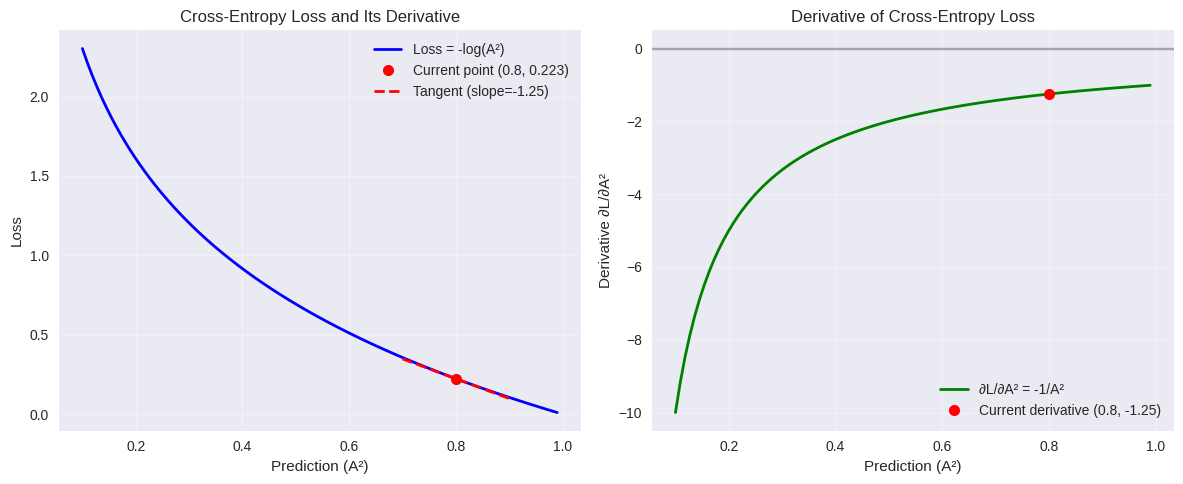

In [41]:
# Visualize the loss function and derivative
A2_range = np.linspace(0.1, 0.99, 100)
loss_range = -np.log(A2_range)  # Loss when y=1

plt.figure(figsize=(12, 5))

# Left plot: Loss function with tangent line
plt.subplot(1, 2, 1)
plt.plot(A2_range, loss_range, 'b-', linewidth=2, label='Loss = -log(A²)')
plt.plot(A2, loss, 'ro', markersize=8, label=f'Current point ({A2}, {loss:.3f})')

# Draw tangent line using analytical derivative
tangent_x = np.linspace(0.7, 0.9, 10)
tangent_y = loss + analytical_derivative * (tangent_x - A2)
plt.plot(tangent_x, tangent_y, 'r--', linewidth=2, label=f'Tangent (slope={analytical_derivative:.2f})')

plt.xlabel('Prediction (A²)')
plt.ylabel('Loss')
plt.title('Cross-Entropy Loss and Its Derivative')
plt.legend()
plt.grid(True, alpha=0.3)

# Right plot: Derivative function
plt.subplot(1, 2, 2)
derivative_range = -1/A2_range  # ∂L/∂A² = -1/A²
plt.plot(A2_range, derivative_range, 'g-', linewidth=2, label="∂L/∂A² = -1/A²")
plt.plot(A2, analytical_derivative, 'ro', markersize=8, label=f'Current derivative ({A2}, {analytical_derivative:.2f})')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.xlabel('Prediction (A²)')
plt.ylabel('Derivative ∂L/∂A²')
plt.title('Derivative of Cross-Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Understanding Derivatives with Interactive Examples

Visualize what derivatives actually mean as slopes of tangent lines. This builds intuition for why gradients tell us the direction to move parameters.

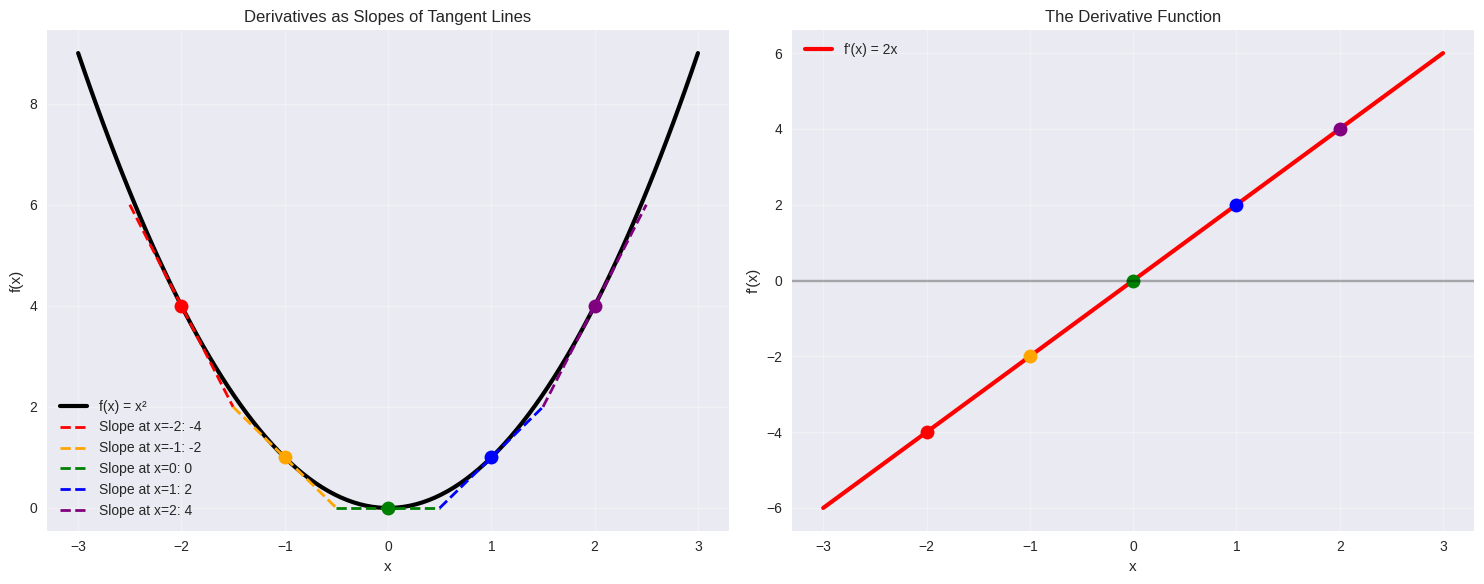

In [42]:
# Visualizing what derivatives mean
def plot_derivative_intuition():
    """Show what derivatives mean visually"""

    # Create function f(x) = x^2
    x = np.linspace(-3, 3, 100)
    y = x**2

    # Points to show tangent lines (derivatives)
    points = [-2, -1, 0, 1, 2]
    colors = ['red', 'orange', 'green', 'blue', 'purple']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Left plot: Function with tangent lines
    ax1.plot(x, y, 'k-', linewidth=3, label='f(x) = x²')

    for i, point in enumerate(points):
        # Function value at point
        y_point = point**2
        # Derivative (slope) at point: f'(x) = 2x
        slope = 2*point

        # Tangent line
        x_tangent = np.linspace(point-0.5, point+0.5, 10)
        y_tangent = y_point + slope * (x_tangent - point)

        ax1.plot(point, y_point, 'o', color=colors[i], markersize=10)
        ax1.plot(x_tangent, y_tangent, '--', color=colors[i], linewidth=2,
                label=f'Slope at x={point}: {slope}')

    ax1.set_xlabel('x')
    ax1.set_ylabel('f(x)')
    ax1.set_title('Derivatives as Slopes of Tangent Lines')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Right plot: Derivative function
    derivative_y = 2*x  # f'(x) = 2x
    ax2.plot(x, derivative_y, 'r-', linewidth=3, label="f'(x) = 2x")

    for i, point in enumerate(points):
        slope = 2*point
        ax2.plot(point, slope, 'o', color=colors[i], markersize=10)

    ax2.set_xlabel('x')
    ax2.set_ylabel("f'(x)")
    ax2.set_title('The Derivative Function')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_derivative_intuition()

#### Sigmoid and Tanh Functions with Their Derivatives

Plot activation functions and their derivatives to understand how gradients flow through different activations. Key insight: sigmoid derivative has max at 0.5, tanh derivative has max at 0.

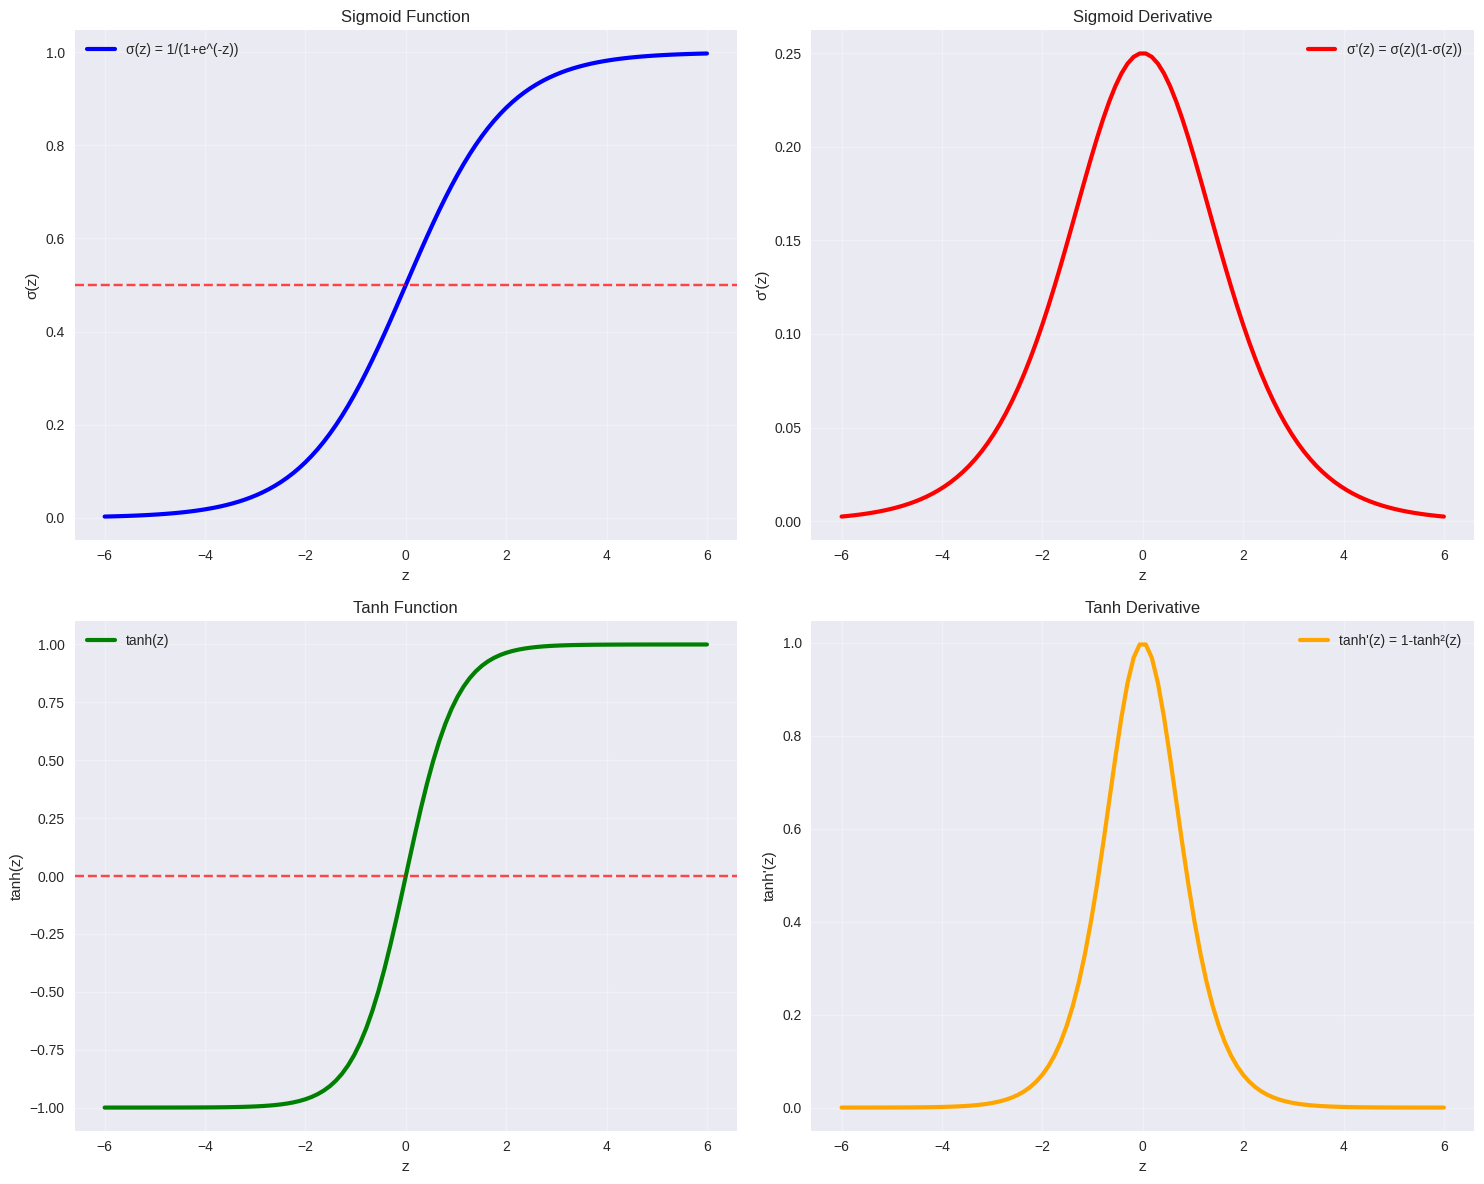

Key values for Sigmoid:
  z=-2: σ(z)=0.119, σ'(z)=0.105
  z=0: σ(z)=0.500, σ'(z)=0.250
  z=2: σ(z)=0.881, σ'(z)=0.105

Key values for Tanh:
  z=-2: tanh(z)=-0.964, tanh'(z)=0.071
  z=0: tanh(z)=0.000, tanh'(z)=1.000
  z=2: tanh(z)=0.964, tanh'(z)=0.071


In [43]:
def plot_activation_functions():
    """Plot activation functions and their derivatives"""

    z = np.linspace(-6, 6, 100)

    # Sigmoid function and derivative
    sigmoid = 1 / (1 + np.exp(-z))
    sigmoid_derivative = sigmoid * (1 - sigmoid)

    # Tanh function and derivative
    tanh = np.tanh(z)
    tanh_derivative = 1 - tanh**2

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # Sigmoid function
    ax1.plot(z, sigmoid, 'b-', linewidth=3, label='σ(z) = 1/(1+e^(-z))')
    ax1.set_title('Sigmoid Function')
    ax1.set_xlabel('z')
    ax1.set_ylabel('σ(z)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='y=0.5')

    # Sigmoid derivative
    ax2.plot(z, sigmoid_derivative, 'r-', linewidth=3, label="σ'(z) = σ(z)(1-σ(z))")
    ax2.set_title('Sigmoid Derivative')
    ax2.set_xlabel('z')
    ax2.set_ylabel("σ'(z)")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # Tanh function
    ax3.plot(z, tanh, 'g-', linewidth=3, label='tanh(z)')
    ax3.set_title('Tanh Function')
    ax3.set_xlabel('z')
    ax3.set_ylabel('tanh(z)')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    ax3.axhline(y=0, color='red', linestyle='--', alpha=0.7)

    # Tanh derivative
    ax4.plot(z, tanh_derivative, 'orange', linewidth=3, label="tanh'(z) = 1-tanh²(z)")
    ax4.set_title('Tanh Derivative')
    ax4.set_xlabel('z')
    ax4.set_ylabel("tanh'(z)")
    ax4.grid(True, alpha=0.3)
    ax4.legend()

    plt.tight_layout()
    plt.show()

    # Print some key values
    print("Key values for Sigmoid:")
    for z_val in [-2, 0, 2]:
        sig = 1/(1 + np.exp(-z_val))
        sig_deriv = sig * (1 - sig)
        print(f"  z={z_val}: σ(z)={sig:.3f}, σ'(z)={sig_deriv:.3f}")

    print("\nKey values for Tanh:")
    for z_val in [-2, 0, 2]:
        tanh_val = np.tanh(z_val)
        tanh_deriv = 1 - tanh_val**2
        print(f"  z={z_val}: tanh(z)={tanh_val:.3f}, tanh'(z)={tanh_deriv:.3f}")

plot_activation_functions()


#### Cross-Entropy Loss Visualization

Visualize the cross-entropy loss function and show why the gradient simplifies to the beautiful result dZ² = A² - y. This is the most important insight in neural networks.

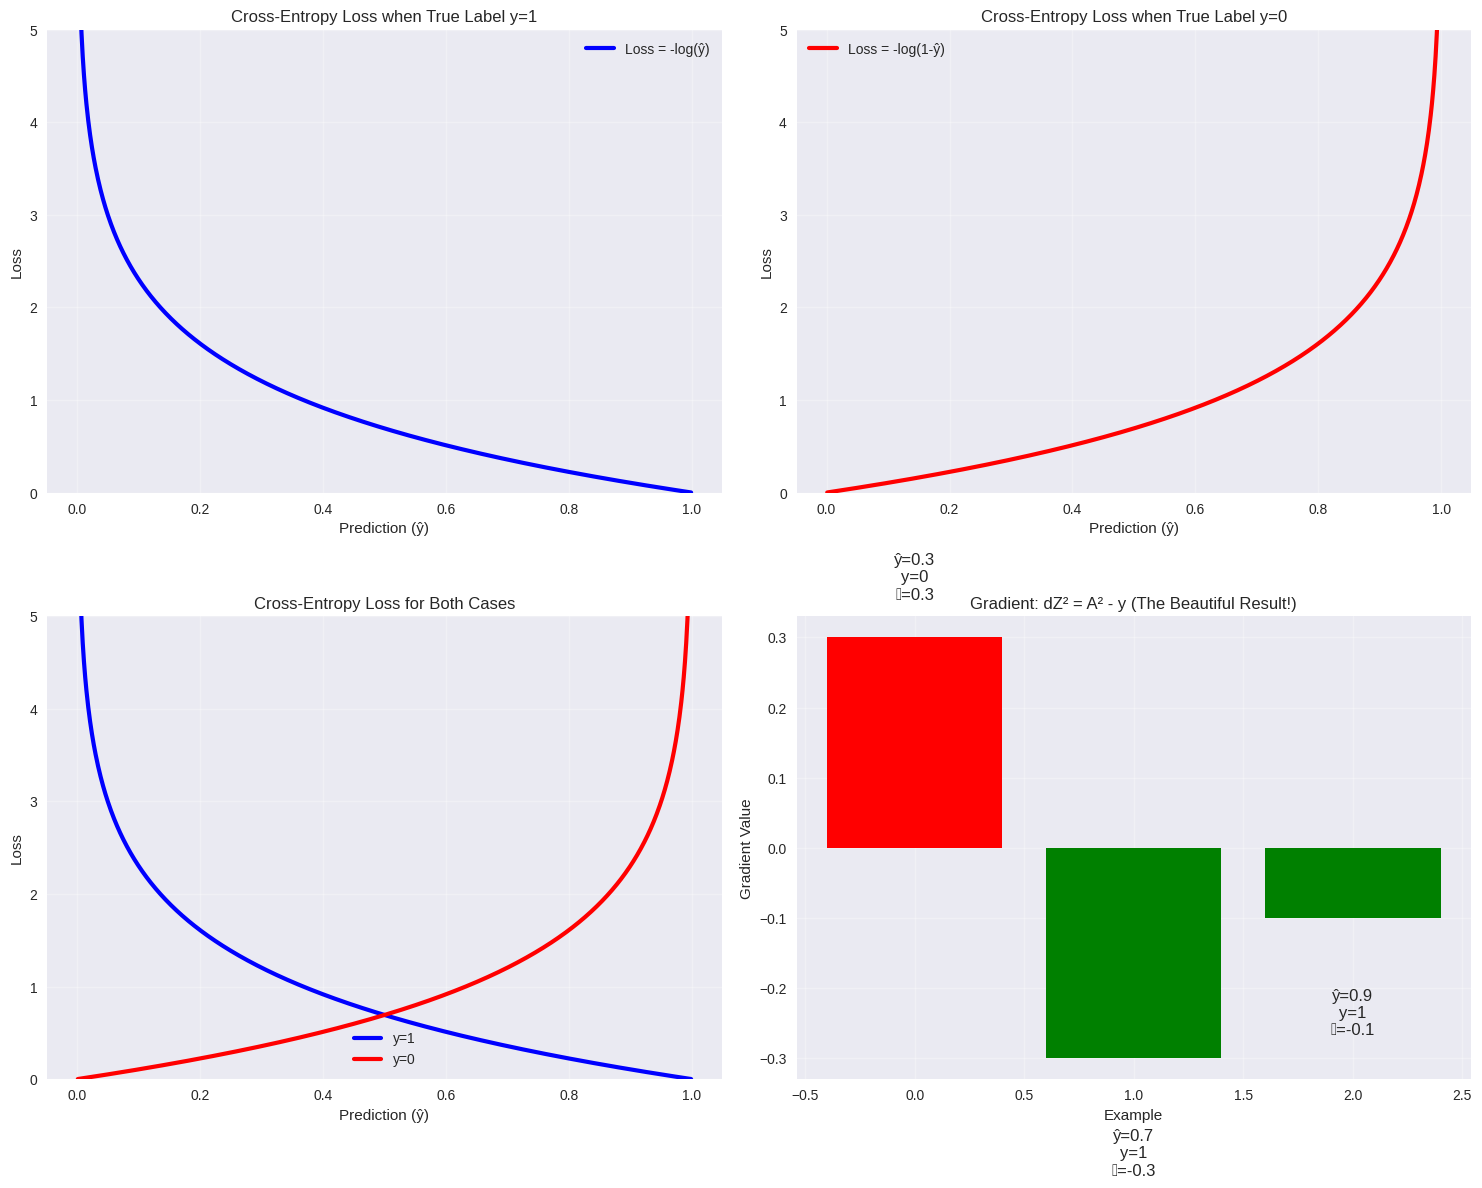

In [44]:
def plot_cross_entropy_loss():
    """Visualize cross-entropy loss and its derivative"""

    # Prediction values (avoiding 0 and 1 for log)
    y_pred = np.linspace(0.001, 0.999, 1000)

    # Cross-entropy loss for y=1 and y=0
    loss_y1 = -np.log(y_pred)  # When true label y=1
    loss_y0 = -np.log(1 - y_pred)  # When true label y=0

    # Derivatives
    deriv_y1 = -1/y_pred  # d/dy_pred[-log(y_pred)]
    deriv_y0 = 1/(1 - y_pred)  # d/dy_pred[-log(1-y_pred)]

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # Loss when y=1
    ax1.plot(y_pred, loss_y1, 'b-', linewidth=3, label='Loss = -log(ŷ)')
    ax1.set_title('Cross-Entropy Loss when True Label y=1')
    ax1.set_xlabel('Prediction (ŷ)')
    ax1.set_ylabel('Loss')
    ax1.set_ylim(0, 5)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Loss when y=0
    ax2.plot(y_pred, loss_y0, 'r-', linewidth=3, label='Loss = -log(1-ŷ)')
    ax2.set_title('Cross-Entropy Loss when True Label y=0')
    ax2.set_xlabel('Prediction (ŷ)')
    ax2.set_ylabel('Loss')
    ax2.set_ylim(0, 5)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # Combined loss visualization
    y_true_1 = 1
    y_true_0 = 0
    combined_loss_y1 = -(y_true_1 * np.log(y_pred) + (1-y_true_1) * np.log(1-y_pred))
    combined_loss_y0 = -(y_true_0 * np.log(y_pred) + (1-y_true_0) * np.log(1-y_pred))

    ax3.plot(y_pred, combined_loss_y1, 'b-', linewidth=3, label='y=1')
    ax3.plot(y_pred, combined_loss_y0, 'r-', linewidth=3, label='y=0')
    ax3.set_title('Cross-Entropy Loss for Both Cases')
    ax3.set_xlabel('Prediction (ŷ)')
    ax3.set_ylabel('Loss')
    ax3.set_ylim(0, 5)
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    # Show the derivative that leads to dZ2 = A2 - y
    # For sigmoid + cross-entropy, the derivative simplifies beautifully
    y_pred_example = np.array([0.3, 0.7, 0.9])
    y_true_example = np.array([0, 1, 1])
    gradient = y_pred_example - y_true_example

    ax4.bar(range(len(gradient)), gradient, color=['red' if g > 0 else 'green' for g in gradient])
    ax4.set_title('Gradient: dZ² = A² - y (The Beautiful Result!)')
    ax4.set_xlabel('Example')
    ax4.set_ylabel('Gradient Value')
    ax4.grid(True, alpha=0.3)

    # Add text annotations
    for i, (pred, true, grad) in enumerate(zip(y_pred_example, y_true_example, gradient)):
        ax4.text(i, grad + 0.05 if grad > 0 else grad - 0.1,
                f'ŷ={pred}\ny={true}\n∇={grad:.1f}',
                ha='center', va='bottom' if grad > 0 else 'top')

    plt.tight_layout()
    plt.show()

plot_cross_entropy_loss()

#### Step-by-Step Mathematical Derivation

 Demonstrate the chain rule with actual numbers to show how we get from ∂L/∂A² and ∂A²/∂Z² to the final result dZ² = A² - y. Makes the math concrete.

In [45]:
def demonstrate_chain_rule():
    """Show chain rule in action with actual numbers"""

    print("🔗 CHAIN RULE DEMONSTRATION")
    print("="*50)

    # Example values
    y_true = 1
    A2 = 0.8  # Final prediction
    Z2 = 1.386  # Pre-activation (sigmoid^(-1)(0.8) ≈ 1.386)

    print(f"Given: y = {y_true}, A² = {A2}, Z² = {Z2:.3f}")
    print()

    # Step 1: dL/dA2
    print("Step 1: How does Loss change with A²?")
    print("L = -y·log(A²) - (1-y)·log(1-A²)")
    print("∂L/∂A² = -y/A² + (1-y)/(1-A²)")

    dL_dA2 = -y_true/A2 + (1-y_true)/(1-A2)
    print(f"∂L/∂A² = -{y_true}/{A2} + {1-y_true}/{1-A2} = {dL_dA2:.3f}")
    print()

    # Step 2: dA2/dZ2
    print("Step 2: How does A² change with Z²?")
    print("A² = sigmoid(Z²)")
    print("∂A²/∂Z² = A²(1-A²)")

    dA2_dZ2 = A2 * (1 - A2)
    print(f"∂A²/∂Z² = {A2}·(1-{A2}) = {A2}·{1-A2} = {dA2_dZ2:.3f}")
    print()

    # Step 3: Chain rule
    print("Step 3: Chain rule to get dL/dZ²")
    print("∂L/∂Z² = (∂L/∂A²) × (∂A²/∂Z²)")

    dL_dZ2_chainrule = dL_dA2 * dA2_dZ2
    print(f"∂L/∂Z² = {dL_dA2:.3f} × {dA2_dZ2:.3f} = {dL_dZ2_chainrule:.3f}")
    print()

    # The beautiful simplification
    print("🌟 THE BEAUTIFUL SIMPLIFICATION:")
    print("Let's expand the algebra...")
    print(f"dL/dZ² = [-{y_true}/{A2} + {1-y_true}/{1-A2}] × [{A2}×{1-A2}]")
    print(f"       = [-{y_true}×{1-A2} + {1-y_true}×{A2}]")
    print(f"       = [-{y_true*(1-A2):.3f} + {(1-y_true)*A2:.3f}]")
    print(f"       = {-(y_true*(1-A2)) + ((1-y_true)*A2):.3f}")

    # Direct calculation
    direct_result = A2 - y_true
    print(f"       = {A2} - {y_true} = {direct_result:.3f}")
    print()
    print(f"✨ RESULT: dZ² = A² - y = {A2} - {y_true} = {direct_result:.3f}")
    print("This matches our chain rule calculation!")

demonstrate_chain_rule()

🔗 CHAIN RULE DEMONSTRATION
Given: y = 1, A² = 0.8, Z² = 1.386

Step 1: How does Loss change with A²?
L = -y·log(A²) - (1-y)·log(1-A²)
∂L/∂A² = -y/A² + (1-y)/(1-A²)
∂L/∂A² = -1/0.8 + 0/0.19999999999999996 = -1.250

Step 2: How does A² change with Z²?
A² = sigmoid(Z²)
∂A²/∂Z² = A²(1-A²)
∂A²/∂Z² = 0.8·(1-0.8) = 0.8·0.19999999999999996 = 0.160

Step 3: Chain rule to get dL/dZ²
∂L/∂Z² = (∂L/∂A²) × (∂A²/∂Z²)
∂L/∂Z² = -1.250 × 0.160 = -0.200

🌟 THE BEAUTIFUL SIMPLIFICATION:
Let's expand the algebra...
dL/dZ² = [-1/0.8 + 0/0.19999999999999996] × [0.8×0.19999999999999996]
       = [-1×0.19999999999999996 + 0×0.8]
       = [-0.200 + 0.000]
       = -0.200
       = 0.8 - 1 = -0.200

✨ RESULT: dZ² = A² - y = 0.8 - 1 = -0.200
This matches our chain rule calculation!


#### Complete Forward Pass Implementation

Implement the forward pass with proper matrix operations and caching. This shows how data flows forward through the network and saves values needed for backprop.

In [46]:
def sigmoid(z):
    """Stable sigmoid implementation"""
    # Clip z to prevent overflow
    z_clipped = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z_clipped))

def forward_pass(X, W1, b1, W2, b2):
    """
    Complete forward pass with intermediate values saved

    Returns:
        cache: Dictionary with all intermediate values for backprop
    """
    # Hidden layer
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)

    # Output layer
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)

    # Save everything we'll need for backprop
    cache = {
        'X': X, 'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2,
        'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2
    }

    return A2, cache

# Test the forward pass
print("🧠 FORWARD PASS DEMONSTRATION")
print("="*40)

# Create a small network
X = np.array([[1], [2]])  # 2 features, 1 example
W1 = np.array([[0.1, 0.2], [0.3, 0.4]])  # 2x2 hidden layer weights
b1 = np.array([[0.1], [0.2]])  # 2x1 hidden biases
W2 = np.array([[0.5, 0.6]])  # 1x2 output weights
b2 = np.array([[0.3]])  # 1x1 output bias

print("Network Architecture: 2 inputs → 2 hidden → 1 output")
print(f"Input X:\n{X}")
print(f"W1 shape: {W1.shape}, b1 shape: {b1.shape}")
print(f"W2 shape: {W2.shape}, b2 shape: {b2.shape}")
print()

# Forward pass
A2, cache = forward_pass(X, W1, b1, W2, b2)

print("Forward pass results:")
print(f"Z1 = W1@X + b1 = \n{cache['Z1']}")
print(f"A1 = tanh(Z1) = \n{cache['A1']}")
print(f"Z2 = W2@A1 + b2 = \n{cache['Z2']}")
print(f"A2 = sigmoid(Z2) = \n{cache['A2']}")
print(f"\nFinal prediction: {A2[0,0]:.4f}")


🧠 FORWARD PASS DEMONSTRATION
Network Architecture: 2 inputs → 2 hidden → 1 output
Input X:
[[1]
 [2]]
W1 shape: (2, 2), b1 shape: (2, 1)
W2 shape: (1, 2), b2 shape: (1, 1)

Forward pass results:
Z1 = W1@X + b1 = 
[[0.6]
 [1.3]]
A1 = tanh(Z1) = 
[[0.53704957]
 [0.86172316]]
Z2 = W2@A1 + b2 = 
[[1.08555868]]
A2 = sigmoid(Z2) = 
[[0.74754447]]

Final prediction: 0.7475


#### Complete Backward Pass Implementation

Implement backpropagation with the exact formulas from our notes. This is the core algorithm - shows how gradients flow backward through the network.

In [47]:
def backward_pass(y_true, cache):
    """
    Complete backward pass implementation

    Args:
        y_true: True labels
        cache: Forward pass cache

    Returns:
        gradients: Dictionary with all gradients
    """

    # Get values from cache
    X = cache['X']
    A1 = cache['A1']
    A2 = cache['A2']
    W2 = cache['W2']

    m = X.shape[1]  # Number of examples

    # Output layer gradients
    dZ2 = A2 - y_true  # The beautiful result!
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    # Hidden layer gradients
    dA1 = np.dot(W2.T, dZ2)
    dZ1 = dA1 * (1 - A1**2)  # tanh derivative
    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

    gradients = {
        'dW2': dW2, 'db2': db2,
        'dW1': dW1, 'db1': db1,
        'dZ2': dZ2, 'dZ1': dZ1,
        'dA1': dA1
    }

    return gradients

# Test backward pass
print("🔄 BACKWARD PASS DEMONSTRATION")
print("="*40)

y_true = np.array([[1]])  # True label

# Compute gradients
gradients = backward_pass(y_true, cache)

print("Backward pass results:")
print(f"dZ2 = A2 - y = {cache['A2'][0,0]:.3f} - {y_true[0,0]} = {gradients['dZ2'][0,0]:.3f}")
print(f"dW2 = dZ2 @ A1.T = \n{gradients['dW2']}")
print(f"db2 = dZ2 = \n{gradients['db2']}")
print()
print(f"dA1 = W2.T @ dZ2 = \n{gradients['dA1']}")
print(f"dZ1 = dA1 * (1-A1²) = \n{gradients['dZ1']}")
print(f"dW1 = dZ1 @ X.T = \n{gradients['dW1']}")
print(f"db1 = dZ1 = \n{gradients['db1']}")

# Show gradient magnitudes
print("\nGradient magnitudes:")
for key, grad in gradients.items():
    if key.startswith('d'):
        magnitude = np.linalg.norm(grad)
        print(f"{key}: {magnitude:.4f}")


🔄 BACKWARD PASS DEMONSTRATION
Backward pass results:
dZ2 = A2 - y = 0.748 - 1 = -0.252
dW2 = dZ2 @ A1.T = 
[[-0.13558113 -0.21754678]]
db2 = dZ2 = 
[[-0.25245553]]

dA1 = W2.T @ dZ2 = 
[[-0.12622777]
 [-0.15147332]]
dZ1 = dA1 * (1-A1²) = 
[[-0.08982087]
 [-0.03899426]]
dW1 = dZ1 @ X.T = 
[[-0.08982087 -0.17964174]
 [-0.03899426 -0.07798852]]
db1 = dZ1 = 
[[-0.08982087]
 [-0.03899426]]

Gradient magnitudes:
dW2: 0.2563
db2: 0.2525
dW1: 0.2190
db1: 0.0979
dZ2: 0.2525
dZ1: 0.0979
dA1: 0.1972


#### Parameter Updates and Learning

Show how gradients are used to update parameters and demonstrate that the network actually learns (cost decreases, predictions improve).

In [48]:
def update_parameters(W1, b1, W2, b2, gradients, learning_rate):
    """Update parameters using gradients"""

    W1_new = W1 - learning_rate * gradients['dW1']
    b1_new = b1 - learning_rate * gradients['db1']
    W2_new = W2 - learning_rate * gradients['dW2']
    b2_new = b2 - learning_rate * gradients['db2']

    return W1_new, b1_new, W2_new, b2_new

def compute_cost(A2, y_true):
    """Compute cross-entropy cost"""
    m = y_true.shape[1]

    # Avoid log(0) by clipping
    A2_clipped = np.clip(A2, 1e-15, 1 - 1e-15)

    cost = -(1/m) * np.sum(y_true * np.log(A2_clipped) +
                          (1-y_true) * np.log(1-A2_clipped))
    return cost

# Demonstrate one complete training iteration
print("🎯 COMPLETE TRAINING ITERATION")
print("="*40)

learning_rate = 0.1
initial_cost = compute_cost(cache['A2'], y_true)

print(f"Before update:")
print(f"  Prediction: {cache['A2'][0,0]:.4f}")
print(f"  True label: {y_true[0,0]}")
print(f"  Cost: {initial_cost:.4f}")
print()

# Update parameters
W1_new, b1_new, W2_new, b2_new = update_parameters(
    W1, b1, W2, b2, gradients, learning_rate)

print(f"Parameter updates (learning_rate = {learning_rate}):")
print(f"  W2: {W2.flatten()} → {W2_new.flatten()}")
print(f"  b2: {b2.flatten()} → {b2_new.flatten()}")
print(f"  W1: {W1.flatten()} → {W1_new.flatten()}")
print(f"  b1: {b1.flatten()} → {b1_new.flatten()}")
print()

# Forward pass with updated parameters
A2_new, _ = forward_pass(X, W1_new, b1_new, W2_new, b2_new)
new_cost = compute_cost(A2_new, y_true)

print(f"After update:")
print(f"  Prediction: {A2_new[0,0]:.4f}")
print(f"  Cost: {new_cost:.4f}")
print(f"  Cost reduction: {initial_cost - new_cost:.4f}")
print()

# Show that we moved in the right direction
direction = "increased" if A2_new[0,0] > cache['A2'][0,0] else "decreased"
print(f"✅ Prediction {direction} (correct since true label = 1)")
print(f"✅ Cost decreased (network is learning!)")

🎯 COMPLETE TRAINING ITERATION
Before update:
  Prediction: 0.7475
  True label: 1
  Cost: 0.2910

Parameter updates (learning_rate = 0.1):
  W2: [0.5 0.6] → [0.51355811 0.62175468]
  b2: [0.3] → [0.32524555]
  W1: [0.1 0.2 0.3 0.4] → [0.10898209 0.21796417 0.30389943 0.40779885]
  b1: [0.1 0.2] → [0.10898209 0.20389943]

After update:
  Prediction: 0.7613
  Cost: 0.2728
  Cost reduction: 0.0182

✅ Prediction increased (correct since true label = 1)
✅ Cost decreased (network is learning!)



#### Training Loop with Visualization

Put everything together in a complete training loop. Visualize how the cost decreases over time and verify the network learns to classify correctly.

🚂 NEURAL NETWORK TRAINING
Training data:
X_train:
[[1.  2.  1.5 2.5]
 [2.  1.  2.5 1.5]]
y_train: [1 0 1 0]

Epoch    0: Cost = 0.693156, Prediction = 0.5001
Epoch  200: Cost = 0.115973, Prediction = 0.8903
Epoch  400: Cost = 0.020095, Prediction = 0.9801
Epoch  600: Cost = 0.010226, Prediction = 0.9898
Epoch  800: Cost = 0.006750, Prediction = 0.9933


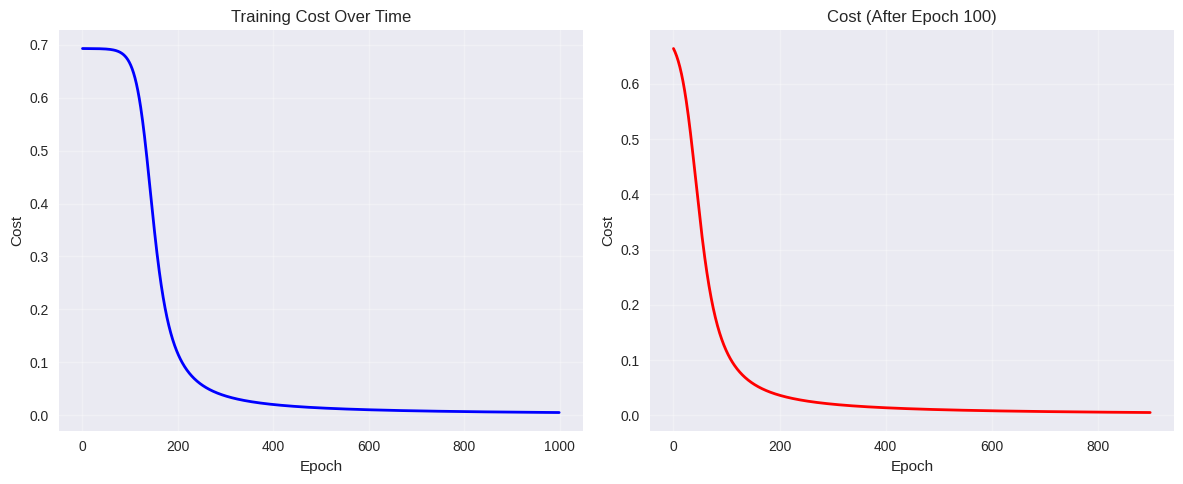


Final results:
True labels:     [1 0 1 0]
Predictions:     [0.99500035 0.0049857  0.99500683 0.00499217]
Predicted class: [1 0 1 0]


In [49]:
def train_network(X, y, hidden_size=4, learning_rate=0.01, epochs=1000, print_every=100):
    """
    Complete neural network training with cost tracking
    """

    # Initialize parameters
    n_x = X.shape[0]  # input size
    n_y = y.shape[0]  # output size

    # Random initialization
    np.random.seed(42)
    W1 = np.random.randn(hidden_size, n_x) * 0.01
    b1 = np.zeros((hidden_size, 1))
    W2 = np.random.randn(n_y, hidden_size) * 0.01
    b2 = np.zeros((n_y, 1))

    costs = []

    for epoch in range(epochs):
        # Forward pass
        A2, cache = forward_pass(X, W1, b1, W2, b2)

        # Compute cost
        cost = compute_cost(A2, y)
        costs.append(cost)

        # Backward pass
        gradients = backward_pass(y, cache)

        # Update parameters
        W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2, gradients, learning_rate)

        # Print progress
        if epoch % print_every == 0:
            print(f"Epoch {epoch:4d}: Cost = {cost:.6f}, Prediction = {A2[0,0]:.4f}")

    return W1, b1, W2, b2, costs

# Create a simple dataset
print("🚂 NEURAL NETWORK TRAINING")
print("="*40)

# Simple 2D dataset for binary classification
X_train = np.array([[1, 2, 1.5, 2.5],
                    [2, 1, 2.5, 1.5]])  # 2 features, 4 examples
y_train = np.array([[1, 0, 1, 0]])      # Binary labels

print("Training data:")
print(f"X_train:\n{X_train}")
print(f"y_train: {y_train.flatten()}")
print()

# Train the network
W1_final, b1_final, W2_final, b2_final, costs = train_network(
    X_train, y_train, hidden_size=3, learning_rate=0.1, epochs=1000, print_every=200)

# Plot training progress
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(costs, 'b-', linewidth=2)
plt.title('Training Cost Over Time')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(costs[100:], 'r-', linewidth=2)  # Zoom in after epoch 100
plt.title('Cost (After Epoch 100)')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Test final predictions
A2_final, _ = forward_pass(X_train, W1_final, b1_final, W2_final, b2_final)
print("\nFinal results:")
print("True labels:    ", y_train.flatten())
print("Predictions:    ", A2_final.flatten())
print("Predicted class:", (A2_final > 0.5).astype(int).flatten())

#### Visualizing Gradient Flow

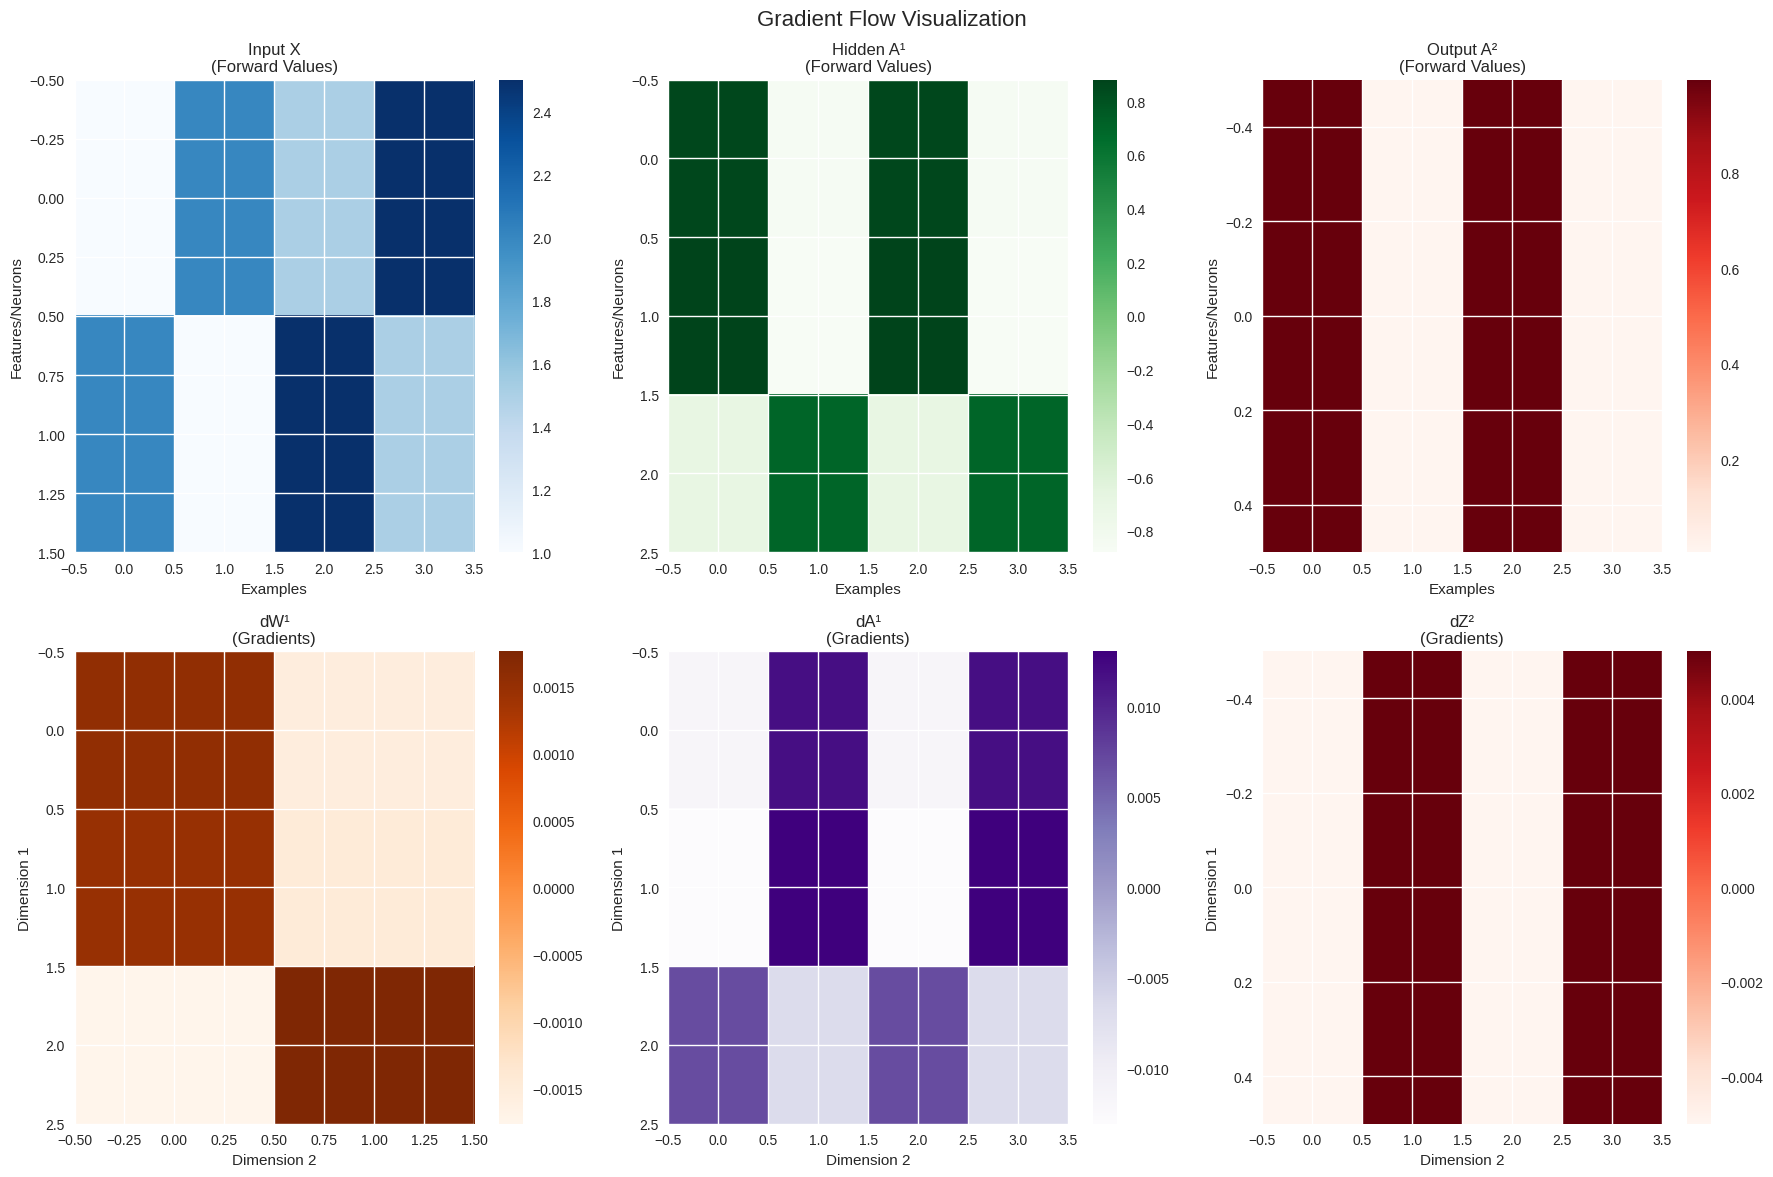

📊 GRADIENT STATISTICS
dW2 : mean=0.004055, max=0.004391
db2 : mean=0.000004, max=0.000004
dW1 : mean=0.001598, max=0.001765
db1 : mean=0.000000, max=0.000001
dZ2 : mean=0.004993, max=0.005000
dZ1 : mean=0.003197, max=0.003532
dA1 : mean=0.010585, max=0.013064


In [50]:
def visualize_gradient_flow(X, y, W1, b1, W2, b2):
    """
    Visualize how gradients flow backward through the network
    """

    # Forward pass
    A2, cache = forward_pass(X, W1, b1, W2, b2)

    # Backward pass
    gradients = backward_pass(y, cache)

    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Forward values
    forward_data = [
        (cache['X'], 'Input X', 'Blues'),
        (cache['A1'], 'Hidden A¹', 'Greens'),
        (cache['A2'], 'Output A²', 'Reds')
    ]

    for i, (data, title, cmap) in enumerate(forward_data):
        im1 = axes[0, i].imshow(data, cmap=cmap, aspect='auto')
        axes[0, i].set_title(f'{title}\n(Forward Values)')
        axes[0, i].set_xlabel('Examples')
        axes[0, i].set_ylabel('Features/Neurons')
        plt.colorbar(im1, ax=axes[0, i])

    # Gradient values
    gradient_data = [
        (gradients['dW1'], 'dW¹', 'Oranges'),
        (gradients['dA1'], 'dA¹', 'Purples'),
        (gradients['dZ2'], 'dZ²', 'Reds')
    ]

    for i, (data, title, cmap) in enumerate(gradient_data):
        im2 = axes[1, i].imshow(data, cmap=cmap, aspect='auto')
        axes[1, i].set_title(f'{title}\n(Gradients)')
        axes[1, i].set_xlabel('Dimension 2' if len(data.shape) > 1 else 'Examples')
        axes[1, i].set_ylabel('Dimension 1')
        plt.colorbar(im2, ax=axes[1, i])

    plt.suptitle('Gradient Flow Visualization', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Print gradient statistics
    print("📊 GRADIENT STATISTICS")
    print("="*30)
    for name, grad in gradients.items():
        if name.startswith('d'):
            mean_grad = np.mean(np.abs(grad))
            max_grad = np.max(np.abs(grad))
            print(f"{name:4s}: mean={mean_grad:.6f}, max={max_grad:.6f}")

# Visualize gradients
visualize_gradient_flow(X_train, y_train, W1_final, b1_final, W2_final, b2_final)

#### Effect of Learning Rate

Training with learning rate: 0.001
Epoch    0: Cost = 0.693156, Prediction = 0.5001
Training with learning rate: 0.01
Epoch    0: Cost = 0.693156, Prediction = 0.5001
Training with learning rate: 0.1
Epoch    0: Cost = 0.693156, Prediction = 0.5001
Training with learning rate: 1.0
Epoch    0: Cost = 0.693156, Prediction = 0.5001


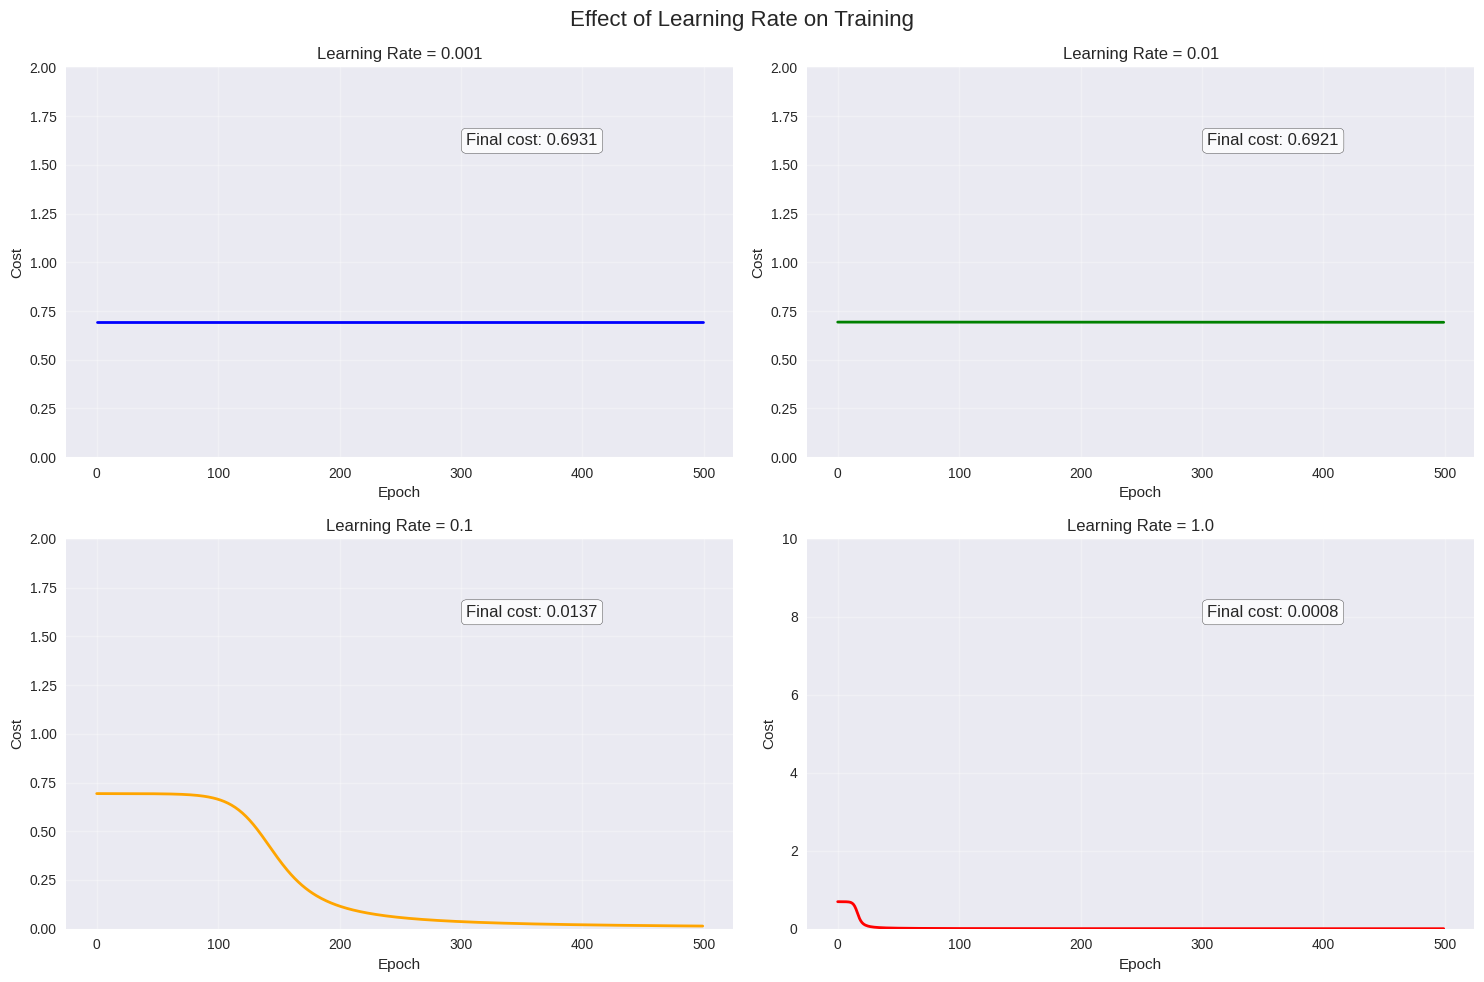


📈 LEARNING RATE ANALYSIS
• lr = 0.001: Too slow, needs more epochs
• lr = 0.01:  Good balance, steady decrease
• lr = 0.1:   Fast convergence, might be optimal
• lr = 1.0:   Too high, might overshoot/oscillate


In [51]:
def compare_learning_rates():
    """
    Compare training with different learning rates
    """

    learning_rates = [0.001, 0.01, 0.1, 1.0]
    colors = ['blue', 'green', 'orange', 'red']

    plt.figure(figsize=(15, 10))

    for i, lr in enumerate(learning_rates):
        print(f"Training with learning rate: {lr}")

        # Train network
        _, _, _, _, costs = train_network(
            X_train, y_train, hidden_size=3, learning_rate=lr,
            epochs=500, print_every=1000)  # No printing

        # Plot results
        plt.subplot(2, 2, i+1)
        plt.plot(costs, color=colors[i], linewidth=2)
        plt.title(f'Learning Rate = {lr}')
        plt.xlabel('Epoch')
        plt.ylabel('Cost')
        plt.grid(True, alpha=0.3)

        # Add final cost as text
        final_cost = costs[-1]
        plt.text(0.6, 0.8, f'Final cost: {final_cost:.4f}',
                transform=plt.gca().transAxes,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

        # Set y-axis limits for better comparison
        if lr <= 0.1:
            plt.ylim(0, 2)
        else:
            plt.ylim(0, 10)

    plt.suptitle('Effect of Learning Rate on Training', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Summary
    print("\n📈 LEARNING RATE ANALYSIS")
    print("="*40)
    print("• lr = 0.001: Too slow, needs more epochs")
    print("• lr = 0.01:  Good balance, steady decrease")
    print("• lr = 0.1:   Fast convergence, might be optimal")
    print("• lr = 1.0:   Too high, might overshoot/oscillate")

compare_learning_rates()

#### Manual Step-by-Step Computation
 

Do a complete forward and backward pass by hand with simple numbers (1 input → 1 hidden → 1 output). This solidifies understanding of each step.

In [52]:
def manual_computation_demo():
    """
    Manual step-by-step computation to verify our understanding
    """

    print("🧮 MANUAL STEP-BY-STEP COMPUTATION")
    print("="*50)

    # Simple 1 input → 1 hidden → 1 output network
    x = 2.0
    w1 = 0.5
    b1 = 0.1
    w2 = 0.8
    b2 = 0.3
    y_true = 1.0

    print("Network: 1 input → 1 hidden (tanh) → 1 output (sigmoid)")
    print(f"Input: x = {x}")
    print(f"Weights: w1 = {w1}, w2 = {w2}")
    print(f"Biases: b1 = {b1}, b2 = {b2}")
    print(f"True label: y = {y_true}")
    print()

    # Forward pass
    print("🔄 FORWARD PASS:")
    print("-" * 20)

    z1 = w1 * x + b1
    print(f"z1 = w1*x + b1 = {w1}*{x} + {b1} = {z1}")

    a1 = np.tanh(z1)
    print(f"a1 = tanh(z1) = tanh({z1}) = {a1:.4f}")

    z2 = w2 * a1 + b2
    print(f"z2 = w2*a1 + b2 = {w2}*{a1:.4f} + {b2} = {z2:.4f}")

    a2 = 1 / (1 + np.exp(-z2))  # sigmoid
    print(f"a2 = sigmoid(z2) = sigmoid({z2:.4f}) = {a2:.4f}")

    # Loss
    loss = -y_true * np.log(a2) - (1-y_true) * np.log(1-a2)
    print(f"\nLoss = -y*log(a2) - (1-y)*log(1-a2)")
    print(f"     = -{y_true}*log({a2:.4f}) - {1-y_true}*log({1-a2:.4f})")
    print(f"     = {loss:.4f}")
    print()

    # Backward pass
    print("🔙 BACKWARD PASS:")
    print("-" * 20)

    # Output layer gradients
    dz2 = a2 - y_true
    print(f"dz2 = a2 - y = {a2:.4f} - {y_true} = {dz2:.4f}")

    dw2 = dz2 * a1
    print(f"dw2 = dz2 * a1 = {dz2:.4f} * {a1:.4f} = {dw2:.4f}")

    db2 = dz2
    print(f"db2 = dz2 = {db2:.4f}")

    # Hidden layer gradients
    da1 = w2 * dz2
    print(f"da1 = w2 * dz2 = {w2} * {dz2:.4f} = {da1:.4f}")

    dz1 = da1 * (1 - a1**2)  # tanh derivative
    print(f"dz1 = da1 * (1-a1²) = {da1:.4f} * (1-{a1:.4f}²) = {da1:.4f} * {1-a1**2:.4f} = {dz1:.4f}")

    dw1 = dz1 * x
    print(f"dw1 = dz1 * x = {dz1:.4f} * {x} = {dw1:.4f}")

    db1 = dz1
    print(f"db1 = dz1 = {db1:.4f}")

    # Parameter updates
    learning_rate = 0.1
    print(f"\n📝 PARAMETER UPDATES (lr = {learning_rate}):")
    print("-" * 30)

    w2_new = w2 - learning_rate * dw2
    b2_new = b2 - learning_rate * db2
    w1_new = w1 - learning_rate * dw1
    b1_new = b1 - learning_rate * db1

    print(f"w2: {w2:.3f} → {w2_new:.3f} (change: {-learning_rate * dw2:+.3f})")
    print(f"b2: {b2:.3f} → {b2_new:.3f} (change: {-learning_rate * db2:+.3f})")
    print(f"w1: {w1:.3f} → {w1_new:.3f} (change: {-learning_rate * dw1:+.3f})")
    print(f"b1: {b1:.3f} → {b1_new:.3f} (change: {-learning_rate * db1:+.3f})")

    # Verify with updated parameters
    z1_new = w1_new * x + b1_new
    a1_new = np.tanh(z1_new)
    z2_new = w2_new * a1_new + b2_new
    a2_new = 1 / (1 + np.exp(-z2_new))
    loss_new = -y_true * np.log(a2_new) - (1-y_true) * np.log(1-a2_new)

    print(f"\n✅ VERIFICATION:")
    print(f"New prediction: {a2:.4f} → {a2_new:.4f}")
    print(f"New loss: {loss:.4f} → {loss_new:.4f}")
    print(f"Loss reduction: {loss - loss_new:.4f}")

    return {
        'old': {'w1': w1, 'b1': b1, 'w2': w2, 'b2': b2, 'loss': loss, 'pred': a2},
        'new': {'w1': w1_new, 'b1': b1_new, 'w2': w2_new, 'b2': b2_new, 'loss': loss_new, 'pred': a2_new},
        'gradients': {'dw1': dw1, 'db1': db1, 'dw2': dw2, 'db2': db2}
    }

manual_result = manual_computation_demo()

🧮 MANUAL STEP-BY-STEP COMPUTATION
Network: 1 input → 1 hidden (tanh) → 1 output (sigmoid)
Input: x = 2.0
Weights: w1 = 0.5, w2 = 0.8
Biases: b1 = 0.1, b2 = 0.3
True label: y = 1.0

🔄 FORWARD PASS:
--------------------
z1 = w1*x + b1 = 0.5*2.0 + 0.1 = 1.1
a1 = tanh(z1) = tanh(1.1) = 0.8005
z2 = w2*a1 + b2 = 0.8*0.8005 + 0.3 = 0.9404
a2 = sigmoid(z2) = sigmoid(0.9404) = 0.7192

Loss = -y*log(a2) - (1-y)*log(1-a2)
     = -1.0*log(0.7192) - 0.0*log(0.2808)
     = 0.3296

🔙 BACKWARD PASS:
--------------------
dz2 = a2 - y = 0.7192 - 1.0 = -0.2808
dw2 = dz2 * a1 = -0.2808 * 0.8005 = -0.2248
db2 = dz2 = -0.2808
da1 = w2 * dz2 = 0.8 * -0.2808 = -0.2247
dz1 = da1 * (1-a1²) = -0.2247 * (1-0.8005²) = -0.2247 * 0.3592 = -0.0807
dw1 = dz1 * x = -0.0807 * 2.0 = -0.1614
db1 = dz1 = -0.0807

📝 PARAMETER UPDATES (lr = 0.1):
------------------------------
w2: 0.800 → 0.822 (change: +0.022)
b2: 0.300 → 0.328 (change: +0.028)
w1: 0.500 → 0.516 (change: +0.016)
b1: 0.100 → 0.108 (change: +0.008)

✅ VERIFIC

#### MAIN CODE

### Mathematical Derivation

In [53]:
def explain_backpropagation_math():
    """
    Explain the 6 key backpropagation equations from the notes
    """
    print("\nBACKPROPAGATION EQUATIONS")
    print("=" * 30)

    print("The 6 key equations:")
    print("1. dZ[2] = A[2] - Y")
    print("2. dW[2] = (1/m) * dZ[2] @ A[1].T")
    print("3. db[2] = (1/m) * sum(dZ[2])")
    print("4. dZ[1] = W[2].T @ dZ[2] * g'[1](Z[1])")
    print("5. dW[1] = (1/m) * dZ[1] @ X.T")
    print("6. db[1] = (1/m) * sum(dZ[1])")
    print()

    print("Where:")
    print("• dZ[l] = ∂J/∂Z[l] (gradient of cost w.r.t. linear output)")
    print("• dW[l] = ∂J/∂W[l] (gradient w.r.t. weights)")
    print("• db[l] = ∂J/∂b[l] (gradient w.r.t. biases)")
    print("• g'[1](Z[1]) = derivative of hidden layer activation")

explain_backpropagation_math()


BACKPROPAGATION EQUATIONS
The 6 key equations:
1. dZ[2] = A[2] - Y
2. dW[2] = (1/m) * dZ[2] @ A[1].T
3. db[2] = (1/m) * sum(dZ[2])
4. dZ[1] = W[2].T @ dZ[2] * g'[1](Z[1])
5. dW[1] = (1/m) * dZ[1] @ X.T
6. db[1] = (1/m) * sum(dZ[1])

Where:
• dZ[l] = ∂J/∂Z[l] (gradient of cost w.r.t. linear output)
• dW[l] = ∂J/∂W[l] (gradient w.r.t. weights)
• db[l] = ∂J/∂b[l] (gradient w.r.t. biases)
• g'[1](Z[1]) = derivative of hidden layer activation


#### Backpropagation implementation

In [54]:
def backward_propagation(cache, Y, parameters):
    """
    Implement backpropagation using the 6 equations
    """
    m = Y.shape[1]  # Number of examples

    # Retrieve cached values
    A1, A2 = cache["A1"], cache["A2"]
    Z1 = cache["Z1"]
    X = cache["X"]
    W2 = parameters["W2"]

    # Backward propagation: the 6 equations
    dZ2 = A2 - Y                                    # Equation 1
    dW2 = (1/m) * np.dot(dZ2, A1.T)               # Equation 2
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)  # Equation 3

    dA1 = np.dot(W2.T, dZ2)
    dZ1 = dA1 * (1 - np.power(A1, 2))             # Equation 4 (tanh derivative)
    dW1 = (1/m) * np.dot(dZ1, X.T)                # Equation 5
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)  # Equation 6

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

In [55]:
# Test backpropagation
print("\nBACKPROPAGATION TEST")
print("=" * 20)

# Use our previous forward pass result
Y_test = np.array([[1, 0, 1]])  # True labels for 3 examples

grads = backward_propagation(cache_vec, Y_test, parameters)

print("Computed gradients:")
for key, grad in grads.items():
    print(f"{key} shape: {grad.shape}")


BACKPROPAGATION TEST
Computed gradients:
dW1 shape: (4, 3)
db1 shape: (4, 1)
dW2 shape: (1, 4)
db2 shape: (1, 1)


## 5. Cost Function and Training

#### Cost Function Implementation

In [56]:
def compute_cost(A2, Y):
    """
    Compute the cross-entropy cost
    J = -(1/m) * sum(Y*log(A2) + (1-Y)*log(1-A2))
    """
    m = Y.shape[1]

    # Cross-entropy cost
    logprobs = np.multiply(Y, np.log(A2)) + np.multiply(1-Y, np.log(1-A2))
    cost = -np.sum(logprobs) / m

    return np.squeeze(cost)

In [57]:
# Test cost computation
cost = compute_cost(A2_vec, Y_test)
print(f"\nCost: {cost:.4f}")


Cost: 0.6931


#### Parameter Updates

In [58]:
def update_parameters(parameters, grads, learning_rate):
    """
    Update parameters using gradient descent
    W = W - learning_rate * dW
    """
    parameters["W1"] = parameters["W1"] - learning_rate * grads["dW1"]
    parameters["b1"] = parameters["b1"] - learning_rate * grads["db1"]
    parameters["W2"] = parameters["W2"] - learning_rate * grads["dW2"]
    parameters["b2"] = parameters["b2"] - learning_rate * grads["db2"]

    return parameters

In [59]:
# Test parameter update
print("\nPARAMETER UPDATE TEST")
print("=" * 25)

print("Before update - W1[0,0]:", parameters["W1"][0,0])
parameters = update_parameters(parameters, grads, learning_rate=0.1)
print("After update - W1[0,0]:", parameters["W1"][0,0])


PARAMETER UPDATE TEST
Before update - W1[0,0]: -0.004167578474054706
After update - W1[0,0]: -0.004168267879369932


## 6. Complete Neural Network Implementation

#### Full Neural Network Class

##### Overview
This code implements a **2-layer neural network** (also called a shallow neural network) from scratch using NumPy. The network has one hidden layer and uses binary classification with a sigmoid output activation.

##### Architecture
- **Input Layer**: `n_x` features
- **Hidden Layer**: `n_h` neurons with tanh activation  
- **Output Layer**: `n_y` neurons (typically 1 for binary classification) with sigmoid activation

##### Data Flow Through the Network

```
Input (X) → Hidden Layer → Output Layer → Prediction
   ↓             ↓              ↓
  n_x    →     n_h      →     n_y
```

##### Class Structure and Methods

###### 1. `__init__(self, n_x, n_h, n_y, learning_rate=0.01)`
**Purpose**: Initialize the neural network with specified architecture and hyperparameters.

**Parameters**:
- `n_x`: Number of input features
- `n_h`: Number of hidden units
- `n_y`: Number of output units
- `learning_rate`: Step size for gradient descent

**What it does**:
- Stores network dimensions
- Initializes parameters (weights and biases)
- Creates empty list to track training costs

###### 2. `initialize_parameters(self)`
**Purpose**: Initialize weights and biases for both layers.

**Implementation Details**:
- **W1**: Hidden layer weights `(n_h, n_x)` - randomly initialized with small values (×0.01)
- **b1**: Hidden layer bias `(n_h, 1)` - initialized to zeros
- **W2**: Output layer weights `(n_y, n_h)` - randomly initialized with small values (×0.01)
- **b2**: Output layer bias `(n_y, 1)` - initialized to zeros

**Why small random weights?** Prevents symmetry breaking and helps with gradient flow.

###### 3. `forward_propagation(self, X)`
**Purpose**: Compute predictions by passing data forward through the network.

**Data Flow**:
```
Input X → Linear: Z1 = W1·X + b1 → Tanh: A1 = tanh(Z1)
       → Linear: Z2 = W2·A1 + b2 → Sigmoid: A2 = σ(Z2)
```

**Step-by-step**:
1. **First layer**: `Z1 = np.dot(W1, X) + b1`
2. **Hidden activation**: `A1 = np.tanh(Z1)` (tanh activation)
3. **Second layer**: `Z2 = np.dot(W2, A1) + b2`
4. **Output activation**: `A2 = 1/(1 + exp(-Z2))` (sigmoid activation)

**Returns**: Final predictions (A2) and cache of intermediate values

###### 4. `compute_cost(self, A2, Y)`
**Purpose**: Calculate the cross-entropy loss function.

**Formula**:
```
Cost = -1/m * Σ[Y·log(A2) + (1-Y)·log(1-A2)]
```

**Why cross-entropy?** It's the standard loss function for binary classification that penalizes confident wrong predictions heavily.

###### 5. `backward_propagation(self, cache, Y)`
**Purpose**: Compute gradients using backpropagation to update parameters.

**The 6 Key Equations** (working backwards):
1. **dZ2 = A2 - Y** (output error)
2. **dW2 = (1/m) * dZ2 · A1^T** (output weight gradients)
3. **db2 = (1/m) * sum(dZ2)** (output bias gradients)
4. **dA1 = W2^T · dZ2** (hidden layer error)
5. **dZ1 = dA1 * (1 - A1²)** (tanh derivative: 1 - tanh²(x))
6. **dW1 = (1/m) * dZ1 · X^T** (hidden weight gradients)
7. **db1 = (1/m) * sum(dZ1)** (hidden bias gradients)

###### 6. `update_parameters(self, grads)`
**Purpose**: Update all parameters using gradient descent.

**Updates**:
- `W1 -= learning_rate × dW1`
- `b1 -= learning_rate × db1` 
- `W2 -= learning_rate × dW2`
- `b2 -= learning_rate × db2`

###### 7. `train(self, X, Y, num_iterations=1000, print_cost=True)`
**Purpose**: Main training loop that orchestrates the entire learning process.

**Training Process**:
1. **Forward pass**: Get predictions
2. **Compute cost**: Measure current error
3. **Backward pass**: Calculate gradients
4. **Update parameters**: Improve weights/biases
5. **Repeat** for specified iterations

###### 8. `predict(self, X)`
**Purpose**: Make binary predictions on new data.

**Process**:
1. Run forward propagation to get probabilities
2. Convert probabilities to binary predictions (>0.5 → 1, ≤0.5 → 0)

##### Key Neural Network Concepts Illustrated

###### Vectorization
- All operations use NumPy's vectorized operations
- Can process multiple training examples simultaneously
- Much faster than iterating through examples one by one

###### Activation Functions
- **Tanh** (hidden layer): Outputs between -1 and 1, helps with gradient flow
- **Sigmoid** (output layer): Outputs between 0 and 1, perfect for binary classification probabilities

###### Matrix Dimensions
- Careful attention to matrix shapes ensures proper broadcasting
- **X**: `(n_x, m)` where m is number of training examples
- **W1**: `(n_h, n_x)`, **W2**: `(n_y, n_h)`
- **Z1, A1**: `(n_h, m)`, **Z2, A2**: `(n_y, m)`

###### Learning Process
The network learns by:
1. Making predictions (forward prop)
2. Measuring errors (cost function)
3. Computing how to adjust parameters (backprop)
4. Making small improvements (gradient descent)
5. Repeating until convergence

##### Usage Example
```python
# Create network: 2 input features, 4 hidden units, 1 output
nn = NeuralNetwork(n_x=2, n_h=4, n_y=1, learning_rate=0.01)

# Train on data
nn.train(X_train, Y_train, num_iterations=10000)

# Make predictions
predictions = nn.predict(X_test)
```

This implementation demonstrates the fundamental building blocks of deep learning: forward propagation, cost computation, backpropagation, and parameter updates - all the core concepts you'll use in more complex networks!

In [60]:
class NeuralNetwork:
    """
    2-Layer Neural Network Implementation
    """

    def __init__(self, n_x, n_h, n_y, learning_rate= 0.01):
        self.n_x = n_x
        self.n_h = n_h
        self.n_y = n_y
        self.learning_rate = learning_rate
        self.parameters = self.initialize_parameters()
        self.costs = []

    def initialize_parameters(self):
        """Initialize parameters randomly"""
        np.random.seed(2)

        W1 = np.random.randn(self.n_h, self.n_x) * 0.01
        b1 = np.zeros((self.n_h, 1))
        W2 = np.random.randn(self.n_y, self.n_h) * 0.01
        b2 = np.zeros((self.n_y, 1))

        return {
            "W1" : W1,
            "b1" : b1,
            "W2" : W2,
            "b2" : b2
        }
    
    def forward_propagation(self, X):
        """Forward propagation"""
        W1, b1 = self.parameters["W1"], self.parameters["b1"]
        W2, b2 = self.parameters["W2"], self.parameters["b2"]

        Z1 = np.dot(W1, X) + b1
        A1 = np.tanh(Z1)
        Z2 = np.dot(W2, A1) + b2
        A2 = 1 / (1 + np.exp(-Z2))

        cache = {
            "Z1" : Z1,
            "A1" : A1,
            "Z2" : Z2,
            "A2" : A2,
            "X"  : X
        }

        return A2, cache
    
    def compute_cost(self, A2, Y):
        """Compute cross-entropy cost"""
        m = Y.shape[1]
        logprobs = np.multiply(Y, np.log(A2)) + np.multiply(1-Y, np.log(1-A2))
        cost = -np.sum(logprobs) / m

        return np.squeeze(cost)
    
    def backward_propagation(self, cache, Y):
        """Backward propagation"""
        m = Y.shape[1]

        A1, A2 = cache["A1"], cache["A2"]
        Z1 = cache["Z1"]
        X = cache["X"]
        W2 = self.parameters["W2"]

        # The 6 equations
        dZ2 = A2 - Y
        dW2 = (1/m) * np.dot(dZ2, A1.T)
        db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

        dA1 = np.dot(W2.T, dZ2)
        dZ1 = dA1 * (1 - np.power(A1, 2))
        dW1 = (1/m) * np.dot(dZ1, X.T)
        db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

        return {
            "dW1" : dW1,
            "db1" : db1,
            "dW2" : dW2,
            "db2" : db2
        }
    
    def update_parameters(self, grads):
        """Update parameters using gradient descent"""
        self.parameters["W1"] -= self.learning_rate * grads["dW1"]
        self.parameters["b1"] -= self.learning_rate * grads["db1"]
        self.parameters["W2"] -= self.learning_rate * grads["dW2"]
        self.parameters["b2"] -= self.learning_rate * grads["db2"]

    def train(self, X, Y, num_iterations=1000, print_cost = True):
        """Train the neural network"""

        for i in range(num_iterations):
            # Forward propagation
            A2, cache = self.forward_propagation(X)

            # Compute cost
            cost = self.compute_cost(A2, Y)
            self.costs.append(cost)

            # Backward propagation
            grads = self.backward_propagation(cache, Y)

            # Update parameters
            self.update_parameters(grads)

            # Print cost
            if print_cost and i % 1000 == 0:
                print(f"Cost after iteration {i}: {cost:.6f}")

    def predict(self, X):
        """Make predictions"""
        A2, _ = self.forward_propagation(X)
        predictions = (A2> 0.5).astype(int)
        return predictions
    
print("Neural Network class implemented!")

Neural Network class implemented!


## 7.Testing on Real Data

#### XOR Problem (Classic Non-Linear Problem)

#### The XOR Problem - Why This Test Matters

##### What is XOR?

The **XOR (Exclusive OR) problem** is a classic benchmark in machine learning that demonstrates why we need neural networks with hidden layers.

**XOR Truth Table:**
- (0,0) → 0
- (0,1) → 1  
- (1,0) → 1
- (1,1) → 0

**Rule: Output is 1 only when inputs are different**

##### Why XOR is Important

###### The Linear Separability Problem

- Simple algorithms like logistic regression can only draw **straight lines** to separate data
- XOR data points cannot be separated by any single straight line
- You need a **curved decision boundary** to solve XOR

###### Visual Example

```
x2
 1  |  🔴(0,1)→1    🔵(1,1)→0
    |
 0  |  🔵(0,0)→0    🔴(1,0)→1
    |________________
       0            1     x1
```

No single straight line can separate the red points (output=1) from blue points (output=0)!

##### Why Neural Networks Solve This

###### Hidden Layer Magic

- The hidden layer learns to **transform** the input space
- Creates new features that make the problem linearly separable
- The network essentially learns to "bend" the decision boundary

###### What the Network Learns

1. **Hidden neurons** detect patterns like "is x1 different from x2?"
2. **Output neuron** combines these patterns to make final decision

##### Historical Significance

- **1960s**: Perceptrons (single layer) couldn't solve XOR → "AI Winter"
- **1980s**: Multi-layer networks with backpropagation solved XOR → "AI Renaissance"
- **Today**: XOR remains the "Hello World" of neural networks

##### Why This Test is Perfect

This test shows your 2-layer network can learn **non-linear patterns** that simpler algorithms cannot handle - which is the fundamental power of neural networks! When your network achieves ~100% accuracy on XOR, it proves the hidden layer is successfully learning to transform the input space.


TESTING ON XOR PROBLEM
XOR Truth Table:
x1 | x2 | output
---|----| ------
 0 |  0 |   0
 0 |  1 |   1
 1 |  0 |   1
 1 |  1 |   0
Cost after iteration 0: 0.693147
Cost after iteration 1000: 0.693147
Cost after iteration 2000: 0.693147
Cost after iteration 3000: 0.693147
Cost after iteration 4000: 0.693147
Cost after iteration 5000: 0.693147
Cost after iteration 6000: 0.693147
Cost after iteration 7000: 0.693147
Cost after iteration 8000: 0.693147
Cost after iteration 9000: 0.693147
Cost after iteration 10000: 0.693147
Cost after iteration 11000: 0.693147
Cost after iteration 12000: 0.693147
Cost after iteration 13000: 0.693147
Cost after iteration 14000: 0.693147
Cost after iteration 15000: 0.693147
Cost after iteration 16000: 0.693147
Cost after iteration 17000: 0.693147
Cost after iteration 18000: 0.693147
Cost after iteration 19000: 0.693147
Cost after iteration 20000: 0.693147
Cost after iteration 21000: 0.693147
Cost after iteration 22000: 0.693147
Cost after iteration 23000: 0.6

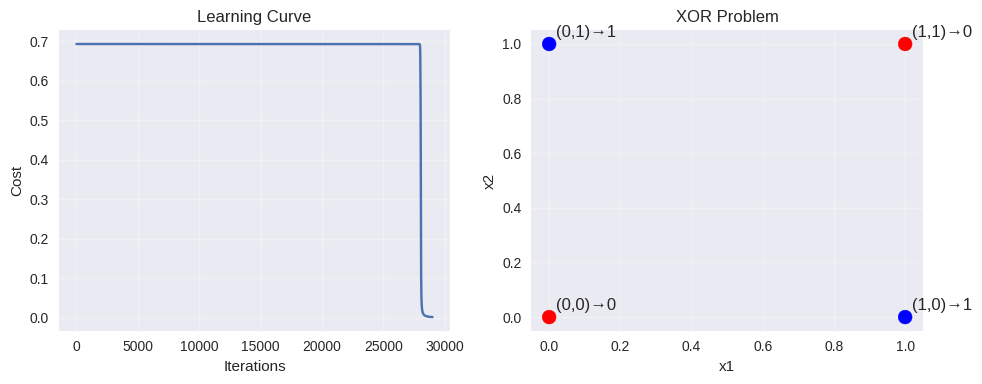

In [61]:
def test_xor_problem():
    """
    Test our neural network on the XOR problem
    XOR is not linearly separable - perfect test for neural networks
    """
    print("\nTESTING ON XOR PROBLEM")
    print("=" * 25)

    # XOR dataset
    X_xor = np.array([
        [0, 0, 1, 1],
        [0, 1, 0, 1]
    ])

    Y_xor = np.array([
        [0, 1, 1, 0]
    ])

    print("XOR Truth Table:")
    print("x1 | x2 | output")
    print("---|----| ------")
    for i in range(4):
        print(f" {X_xor[0,i]} |  {X_xor[1,i]} |   {Y_xor[0,i]}")

    # Create and train neural network
    nn = NeuralNetwork(n_x=2, n_h=4, n_y=1, learning_rate=1.2)
    nn.train(X_xor, Y_xor, num_iterations=29000, print_cost=True)

    # Test predictions
    predictions = nn.predict(X_xor)

    print(f"\nFinal Results:")
    print(f"Predictions: {predictions.ravel()}")
    print(f"True labels: {Y_xor.ravel()}")
    print(f"Accuracy: {np.mean(predictions == Y_xor) * 100:.1f}%")

    # EXTRA CODE - VISUALIZATION
    # Plot learning curve
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(nn.costs)
    plt.title('Learning Curve')
    plt.xlabel('Iterations')
    plt.ylabel('Cost')
    plt.grid(True, alpha=0.3)

    # Visualize XOR data
    plt.subplot(1, 2, 2)
    colors = ['red' if y == 0 else 'blue' for y in Y_xor.ravel()]
    plt.scatter(X_xor[0, :], X_xor[1, :], c=colors, s=100)
    plt.title('XOR Problem')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.grid(True, alpha=0.3)

    # Add labels
    for i in range(4):
        plt.annotate(f'({X_xor[0,i]},{X_xor[1,i]})→{Y_xor[0,i]}',
                    (X_xor[0,i], X_xor[1,i]), xytext=(5, 5),
                    textcoords='offset points')

    plt.tight_layout()
    plt.show()


    return nn


# Test XOR
xor_model = test_xor_problem()
    

#### Moon Dataset

#### The Moon Dataset - Real-World Non-Linear Classification

##### What is the Moon Dataset?

The **Moon Dataset** is a synthetic 2D dataset that creates two interleaving half-circles (crescents) that look like moons. It's a popular benchmark for testing non-linear classification algorithms.

**Dataset Characteristics:**
- **300 samples** with **2 features** (x and y coordinates)
- **Two classes** forming crescent/moon shapes
- **Noise parameter (0.2)** adds realistic data scatter
- **Non-linearly separable** - no straight line can separate the classes

##### Why This Dataset is Important

###### Real-World Complexity
- Unlike XOR's simple 4-point problem, this has **300 data points**
- Mimics real-world scenarios where classes have **complex, curved boundaries**
- Tests the network's ability to handle **noisy data**

###### Non-Linear Decision Boundary
```
    Class 1 (🔴)
   ╭─────────╮
  ╱           ╲
 ╱             ╲
╱    Class 0    ╲
╲    (🔵)       ╱
 ╲             ╱
  ╲___________╱
    Class 1 (🔴)
```

The decision boundary needs to be a **curved S-shape** to separate the two moon crescents.

##### What This Test Demonstrates

###### Scalability
- Shows your network can handle **larger datasets** (300 vs 4 points)
- Tests performance with **realistic data volumes**

###### Generalization
- **Noise** in the data tests if the network learns true patterns vs memorizing
- Multiple data points test the network's ability to **generalize** beyond training examples

###### Network Architecture Impact
- Uses **10 hidden neurons** (vs 4 for XOR) to handle increased complexity
- Demonstrates how **network size** scales with problem difficulty

##### Key Differences from XOR

| Aspect | XOR | Moon Dataset |
|--------|-----|--------------|
| **Data Points** | 4 | 300 |
| **Complexity** | Simple logical function | Curved geometric shapes |
| **Noise** | None | 20% noise added |
| **Hidden Units** | 4 | 10 |
| **Real-World Relevance** | Theoretical | More realistic |

##### What Success Looks Like

**Good Performance Indicators:**
- **Accuracy > 85%**: Shows the network learned the pattern
- **Smooth Learning Curve**: Cost should decrease consistently
- **Clear Decision Boundary**: Predictions should follow the moon shapes

**Why This Matters:**
This test proves your neural network can solve **realistic classification problems** with curved decision boundaries and noisy data - the foundation for more complex applications like image recognition, medical diagnosis, and financial modeling.


TESTING ON MOON DATASET
Dataset: 300 examples, 2 features
Accuracy: 87.3%


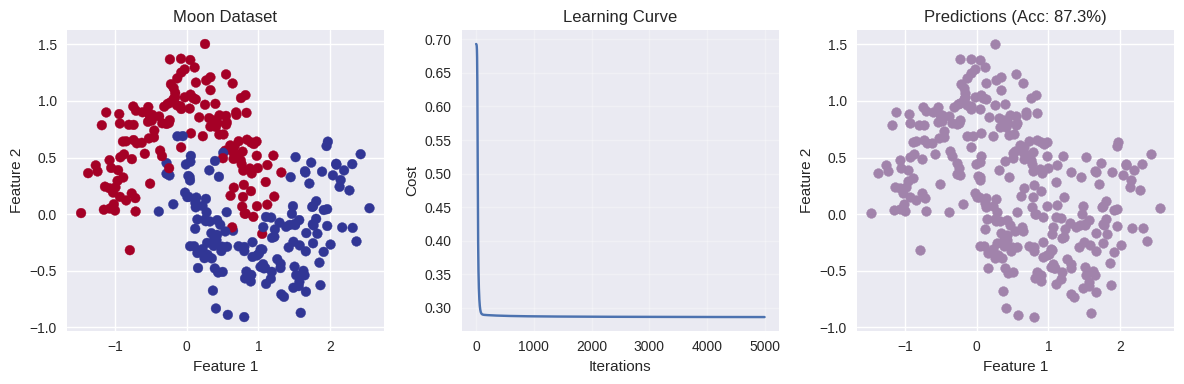

In [62]:
def test_moon_dataset():
    """
    Test on moon-shaped dataset (more realistic example)
    """
    print("\nTESTING ON MOON DATASET")
    print("=" * 25)

    # Generate moon dataset
    from sklearn.datasets import make_moons
    X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)
    X_moons = X_moons.T
    y_moons = y_moons.reshape(1, -1)

    print(f"Dataset: {X_moons.shape[1]} examples, {X_moons.shape[0]} features")

    # Visualize dataset
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.scatter(X_moons[0, :], X_moons[1, :], c=y_moons.ravel(), cmap='RdYlBu')
    plt.title('Moon Dataset')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

    # Train neural network
    nn_moon = NeuralNetwork(n_x=2, n_h=10, n_y=1, learning_rate=0.5)
    nn_moon.train(X_moons, y_moons, num_iterations=5000, print_cost=False)

    #Evaluate
    prediction = nn_moon.predict(X_moons)
    accuracy = np.mean(prediction == y_moons) * 100

    print(f"Accuracy: {accuracy:.1f}%")

    # Plot results
    plt.subplot(1, 3, 2)
    plt.plot(nn_moon.costs)
    plt.title('Learning Curve')
    plt.xlabel('Iterations')
    plt.ylabel('Cost')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.scatter(X_moons[0, :], X_moons[1, :], c=predictions.ravel(), cmap='RdYlBu')
    plt.title(f'Predictions (Acc: {accuracy:.1f}%)')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

    plt.tight_layout()
    plt.show()

    return nn_moon

# Test moon dataset
moon_model = test_moon_dataset()




## 8. random initialization

#### What Happens with Zero Initialization?

In [63]:
def demonstrate_symmetry_problem():
    """
    Demonstrate why zero initialization fails
    """
    import numpy as np

    print("SYMMETRY PROBLEM DEMONSTRATION")
    print("=" * 40)

    # Simple dataset
    X = np.array([[1, 0, 1],
                  [0, 1, 1]])

    # Zero initialization (BAD)
    print("ZERO INITIALIZATION:")
    W1_zero = np.zeros((2, 2))
    b1_zero = np.array([[0.1], [0.2]])  # Different biases

    Z1 = np.dot(W1_zero, X) + b1_zero
    A1 = np.tanh(Z1)

    print("Hidden layer outputs:")
    print(A1)
    print("❌ All columns have same pattern (only scaled by bias)")
    print()

    # Random initialization (GOOD)
    print("RANDOM INITIALIZATION:")
    np.random.seed(1)
    W1_random = np.random.randn(2, 2) * 0.01
    b1_random = np.zeros((2, 1))

    Z1_random = np.dot(W1_random, X) + b1_random
    A1_random = np.tanh(Z1_random)

    print("Hidden layer outputs:")
    print(A1_random)
    print("✅ Each neuron learns different features")

demonstrate_symmetry_problem()

SYMMETRY PROBLEM DEMONSTRATION
ZERO INITIALIZATION:
Hidden layer outputs:
[[0.09966799 0.09966799 0.09966799]
 [0.19737532 0.19737532 0.19737532]]
❌ All columns have same pattern (only scaled by bias)

RANDOM INITIALIZATION:
Hidden layer outputs:
[[ 0.01624203 -0.00611749  0.01012554]
 [-0.00528167 -0.01072927 -0.01601004]]
✅ Each neuron learns different features


#### Correct Random Initialization
**Basic Random Initialization**

In [64]:
def initialize_parameters(n_x, n_h, n_y):
    """
    Initialize parameters randomly for a 2-layer neural network

    Arguments:
    n_x -- size of input layer
    n_h -- size of hidden layer
    n_y -- size of output layer

    Returns:
    parameters -- dictionary containing W1, b1, W2, b2
    """
    np.random.seed(2)  # For reproducibility

    # Initialize weights to small random values
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))

    parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return parameters

**Why 0.01?**

In [66]:
# Too small (0.001) - Weak signals, slow learning
W1 = np.random.randn(n_h, n_x) * 0.001
print("w1 ",W1)

# Just right (0.01) - Good for shallow networks
W2 = np.random.randn(n_h, n_x) * 0.01
print("w2 ",W2)

# Too large (1.0) - Saturated activations, vanishing gradients
W3 = np.random.randn(n_h, n_x) * 1.0
print("w3 ",W3)


w1  [[-1.91835552e-04 -8.87628964e-04 -7.47158294e-04]
 [ 1.69245460e-03  5.08077548e-05 -6.36995647e-04]
 [ 1.90915485e-04  2.10025514e-03  1.20158952e-04]
 [ 6.17203110e-04  3.00170320e-04 -3.52249846e-04]]
w2  [[-0.01142518 -0.00349343 -0.00208894]
 [ 0.00586623  0.00838983  0.00931102]
 [ 0.00285587  0.00885141 -0.00754398]
 [ 0.01252868  0.0051293  -0.00298093]]
w3  [[ 0.48851815 -0.07557171  1.13162939]
 [ 1.51981682  2.18557541 -1.39649634]
 [-1.44411381 -0.50446586  0.16003707]
 [ 0.87616892  0.31563495 -2.02220122]]


#### Why Bias Can Be Zero

In [67]:
def show_bias_zero_ok():
    """
    Show that zero bias initialization works fine
    """
    import numpy as np

    np.random.seed(1)
    W1 = np.random.randn(3, 2) * 0.01  # Random weights
    b1 = np.zeros((3, 1))              # Zero biases
    X = np.array([[1], [0.5]])

    Z1 = np.dot(W1, X) + b1

    print("Weights (different):")
    print(W1)
    print("\nBiases (all zero):")
    print(b1.ravel())
    print("\nLinear outputs (different):")
    print(Z1.ravel())
    print("\n✅ Symmetry broken by random weights, even with zero biases!")

show_bias_zero_ok()

Weights (different):
[[ 0.01624345 -0.00611756]
 [-0.00528172 -0.01072969]
 [ 0.00865408 -0.02301539]]

Biases (all zero):
[0. 0. 0.]

Linear outputs (different):
[ 0.01318467 -0.01064656 -0.00285362]

✅ Symmetry broken by random weights, even with zero biases!
